# Projet IA — HumanForYou : Prédiction de l'Attrition des Employés

**Contexte :** L'entreprise pharmaceutique HumanForYou (Inde, ~4 000 employés) subit un taux de rotation annuel de 15 %. La direction souhaite identifier les facteurs d'influence et prédire quels employés risquent de quitter l'entreprise afin de mettre en place des actions de rétention ciblées.

**Objectif :** Construire un modèle de **classification binaire** capable de prédire la variable cible `Attrition` (Yes / No) à partir des données RH, des évaluations managers, des enquêtes de satisfaction et des horaires de travail.

---
**Plan du notebook :**
1. Préparation de l'environnement
2. Chargement et fusion des données
3. Analyse exploratoire des données (EDA)
4. Ingénierie des caractéristiques (horaires de travail)
5. Préparation des données pour le Machine Learning
6. Entraînement des modèles de classification
7. Comparaison et évaluation des modèles
8. Amélioration du meilleur modèle
9. Interprétation et recommandations

---
## Partie 1 — Préparation de l'environnement

On importe toutes les bibliothèques nécessaires et on configure les paramètres d'affichage pour une meilleure lisibilité.

In [1]:
# Imports généraux
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import zipfile
import os

# Imports scikit-learn
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline

# Modèles de classification
from sklearn.linear_model import LogisticRegression, Perceptron
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# Métriques
from sklearn.metrics import (
    confusion_matrix, classification_report,
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score, accuracy_score
)

# Configuration de l'affichage
plt.rcParams['figure.figsize'] = (12, 6)
sns.set()
sns.set_context('talk')
np.set_printoptions(threshold=20, precision=2, suppress=True)
pd.set_option('display.max_rows', 30)
pd.set_option('display.max_columns', None)
pd.set_option('display.precision', 2)
warnings.filterwarnings('ignore')

print('Environnement prêt ✓')

Environnement prêt ✓


---
## Partie 2 — Chargement et fusion des données

Le service RH nous a fourni 4 sources de données :
- `general_data.csv` : données démographiques et RH de chaque employé
- `employee_survey_data.csv` : enquête qualité de vie au travail (juin 2015)
- `manager_survey_data.csv` : dernière évaluation manager (février 2015)
- `in_out_time.zip` : horaires d'entrée et de sortie journaliers sur 2015

On fusionne les 4 fichiers sur la clé commune `EmployeeID`.

In [2]:
DATA_PATH = 'project_data/'

# --- Chargement des fichiers CSV ---
general    = pd.read_csv(DATA_PATH + 'general_data.csv')
emp_survey = pd.read_csv(DATA_PATH + 'employee_survey_data.csv')
mgr_survey = pd.read_csv(DATA_PATH + 'manager_survey_data.csv')

print('general_data     :', general.shape)
print('employee_survey  :', emp_survey.shape)
print('manager_survey   :', mgr_survey.shape)

general_data     : (4410, 24)
employee_survey  : (4410, 4)
manager_survey   : (4410, 3)


In [3]:
# --- Chargement des horaires depuis le ZIP ---
with zipfile.ZipFile(DATA_PATH + 'in_out_time.zip') as z:
    with z.open('in_time.csv') as f:
        in_time = pd.read_csv(f, index_col=0)
    with z.open('out_time.csv') as f:
        out_time = pd.read_csv(f, index_col=0)

# L'index correspond à l'EmployeeID
in_time.index.name  = 'EmployeeID'
out_time.index.name = 'EmployeeID'

print('in_time  :', in_time.shape)   # lignes = employés, colonnes = jours
print('out_time :', out_time.shape)
in_time.iloc[:3, :5]

in_time  : (4410, 261)
out_time : (4410, 261)


,2015-01-01,2015-01-02,2015-01-05,2015-01-06,2015-01-07
EmployeeID,,,,,
1,NaN,2015-01-02 09:43:45,2015-01-05 10:08:48,2015-01-06 09:54:26,2015-01-07 09:34:31
2,NaN,2015-01-02 10:15:44,2015-01-05 10:21:05,NaN,2015-01-07 09:45:17
3,NaN,2015-01-02 10:17:41,2015-01-05 09:50:50,2015-01-06 10:14:13,2015-01-07 09:47:27


In [4]:
# --- Aperçu de la table principale ---
general.head()

,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3
3,38,No,Non-Travel,Research & Development,2,5,Life Sciences,1,4,Male,3,Human Resources,Married,83210,3.0,Y,11,8,3,13.0,5,8,7,5
4,32,No,Travel_Rarely,Research & Development,10,1,Medical,1,5,Male,1,Sales Executive,Single,23420,4.0,Y,12,8,2,9.0,2,6,0,4


In [5]:
# --- Fusion progressive sur EmployeeID ---
df = general.merge(emp_survey, on='EmployeeID', how='left')
df = df.merge(mgr_survey,  on='EmployeeID', how='left')

print('Données fusionnées :', df.shape)
df.head(3)

Données fusionnées : (4410, 29)


,Age,Attrition,BusinessTravel,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeID,Gender,JobLevel,JobRole,MaritalStatus,MonthlyIncome,NumCompaniesWorked,Over18,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
0,51,No,Travel_Rarely,Sales,6,2,Life Sciences,1,1,Female,1,Healthcare Representative,Married,131160,1.0,Y,11,8,0,1.0,6,1,0,0,3.0,4.0,2.0,3,3
1,31,Yes,Travel_Frequently,Research & Development,10,1,Life Sciences,1,2,Female,1,Research Scientist,Single,41890,0.0,Y,23,8,1,6.0,3,5,1,4,3.0,2.0,4.0,2,4
2,32,No,Travel_Frequently,Research & Development,17,4,Other,1,3,Male,4,Sales Executive,Married,193280,1.0,Y,15,8,3,5.0,2,5,0,3,2.0,2.0,1.0,3,3


---
## Partie 3 — Analyse exploratoire des données (EDA)

Avant de modéliser, on explore les données pour comprendre :
- La structure et les types de variables
- Les valeurs manquantes
- Les distributions (analyse univariée)
- Les relations entre variables et la cible (analyse bivariée)
- La matrice de corrélation

### 3.1 Structure et types de données

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4410 entries, 0 to 4409
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Age                      4410 non-null   int64  
 1   Attrition                4410 non-null   object 
 2   BusinessTravel           4410 non-null   object 
 3   Department               4410 non-null   object 
 4   DistanceFromHome         4410 non-null   int64  
 5   Education                4410 non-null   int64  
 6   EducationField           4410 non-null   object 
 7   EmployeeCount            4410 non-null   int64  
 8   EmployeeID               4410 non-null   int64  
 9   Gender                   4410 non-null   object 
 10  JobLevel                 4410 non-null   int64  
 11  JobRole                  4410 non-null   object 
 12  MaritalStatus            4410 non-null   object 
 13  MonthlyIncome            4410 non-null   int64  
 14  NumCompaniesWorked      

In [7]:
df.describe()

,Age,DistanceFromHome,Education,EmployeeCount,EmployeeID,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating
count,4410.00,4410.00,4410.00,4410.0,4410.00,4410.00,4410.00,4391.00,4410.00,4410.0,4410.00,4401.00,4410.00,4410.00,4410.00,4410.00,4385.00,4390.00,4372.00,4410.00,4410.00
mean,36.92,9.19,2.91,1.0,2205.50,2.06,65029.31,2.69,15.21,8.0,0.79,11.28,2.80,7.01,2.19,4.12,2.72,2.73,2.76,2.73,3.15
std,9.13,8.11,1.02,0.0,1273.20,1.11,47068.89,2.50,3.66,0.0,0.85,7.78,1.29,6.13,3.22,3.57,1.09,1.10,0.71,0.71,0.36
min,18.00,1.00,1.00,1.0,1.00,1.00,10090.00,0.00,11.00,8.0,0.00,0.00,0.00,0.00,0.00,0.00,1.00,1.00,1.00,1.00,3.00
25%,30.00,2.00,2.00,1.0,1103.25,1.00,29110.00,1.00,12.00,8.0,0.00,6.00,2.00,3.00,0.00,2.00,2.00,2.00,2.00,2.00,3.00
50%,36.00,7.00,3.00,1.0,2205.50,2.00,49190.00,2.00,14.00,8.0,1.00,10.00,3.00,5.00,1.00,3.00,3.00,3.00,3.00,3.00,3.00
75%,43.00,14.00,4.00,1.0,3307.75,3.00,83800.00,4.00,18.00,8.0,1.00,15.00,3.00,9.00,3.00,7.00,4.00,4.00,3.00,3.00,3.00
max,60.00,29.00,5.00,1.0,4410.00,5.00,199990.00,9.00,25.00,8.0,3.00,40.00,6.00,40.00,15.00,17.00,4.00,4.00,4.00,4.00,4.00


Attrition
No     3699
Yes     711
Name: count, dtype: int64

Taux d'attrition : 16.1 %


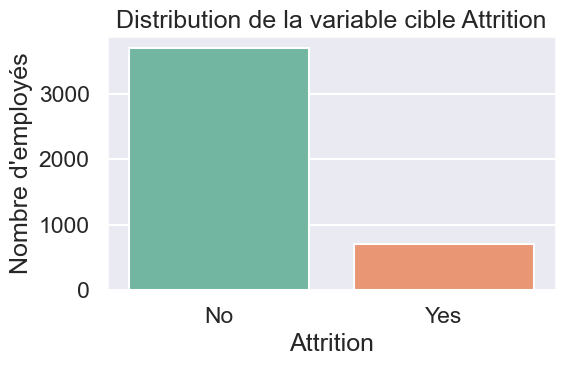

In [8]:
# Distribution de la variable cible
attrition_counts = df['Attrition'].value_counts()
print(attrition_counts)
print(f"\nTaux d'attrition : {attrition_counts['Yes'] / len(df) * 100:.1f} %")

plt.figure(figsize=(6, 4))
sns.countplot(x='Attrition', data=df, palette='Set2')
plt.title("Distribution de la variable cible Attrition")
plt.xlabel("Attrition")
plt.ylabel("Nombre d'employés")
plt.tight_layout()
plt.show()

### 3.2 Valeurs manquantes

Les données de l'enquête employé contiennent des `NA` pour les employés n'ayant pas répondu. On les identifie avant de décider d'un traitement.

Colonnes avec valeurs manquantes :
WorkLifeBalance            38
EnvironmentSatisfaction    25
JobSatisfaction            20
NumCompaniesWorked         19
TotalWorkingYears           9
dtype: int64


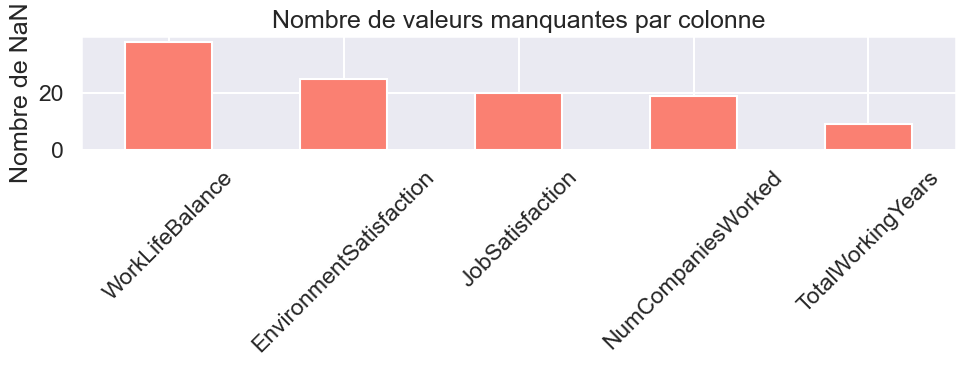

In [9]:
missing = df.isnull().sum()
missing = missing[missing > 0].sort_values(ascending=False)
print("Colonnes avec valeurs manquantes :")
print(missing)

# Visualisation
plt.figure(figsize=(10, 4))
missing.plot(kind='bar', color='salmon')
plt.title('Nombre de valeurs manquantes par colonne')
plt.ylabel('Nombre de NaN')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### 3.3 Suppression des colonnes redondantes ou constantes

Certaines colonnes n'apportent aucune information discriminante :
- `EmployeeCount` et `StandardHours` : valeurs constantes dans tout le fichier
- `Over18` : tous les employés sont majeurs
- `EmployeeID` : simple identifiant, pas une feature

In [10]:
# Vérification des colonnes à supprimer
for col in ['EmployeeCount', 'StandardHours', 'Over18']:
    print(f"{col} → valeurs uniques : {df[col].unique()}")

cols_to_drop = ['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeID']
df.drop(columns=cols_to_drop, inplace=True)

print(f"\nDimensions après nettoyage : {df.shape}")

EmployeeCount → valeurs uniques : [1]
StandardHours → valeurs uniques : [8]
Over18 → valeurs uniques : ['Y']

Dimensions après nettoyage : (4410, 25)


### 3.4 Analyse univariée — Variables numériques

In [11]:
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns.tolist()
print('Variables numériques :', numerical_cols)

Variables numériques : ['Age', 'DistanceFromHome', 'Education', 'JobLevel', 'MonthlyIncome', 'NumCompaniesWorked', 'PercentSalaryHike', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'YearsAtCompany', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'EnvironmentSatisfaction', 'JobSatisfaction', 'WorkLifeBalance', 'JobInvolvement', 'PerformanceRating']


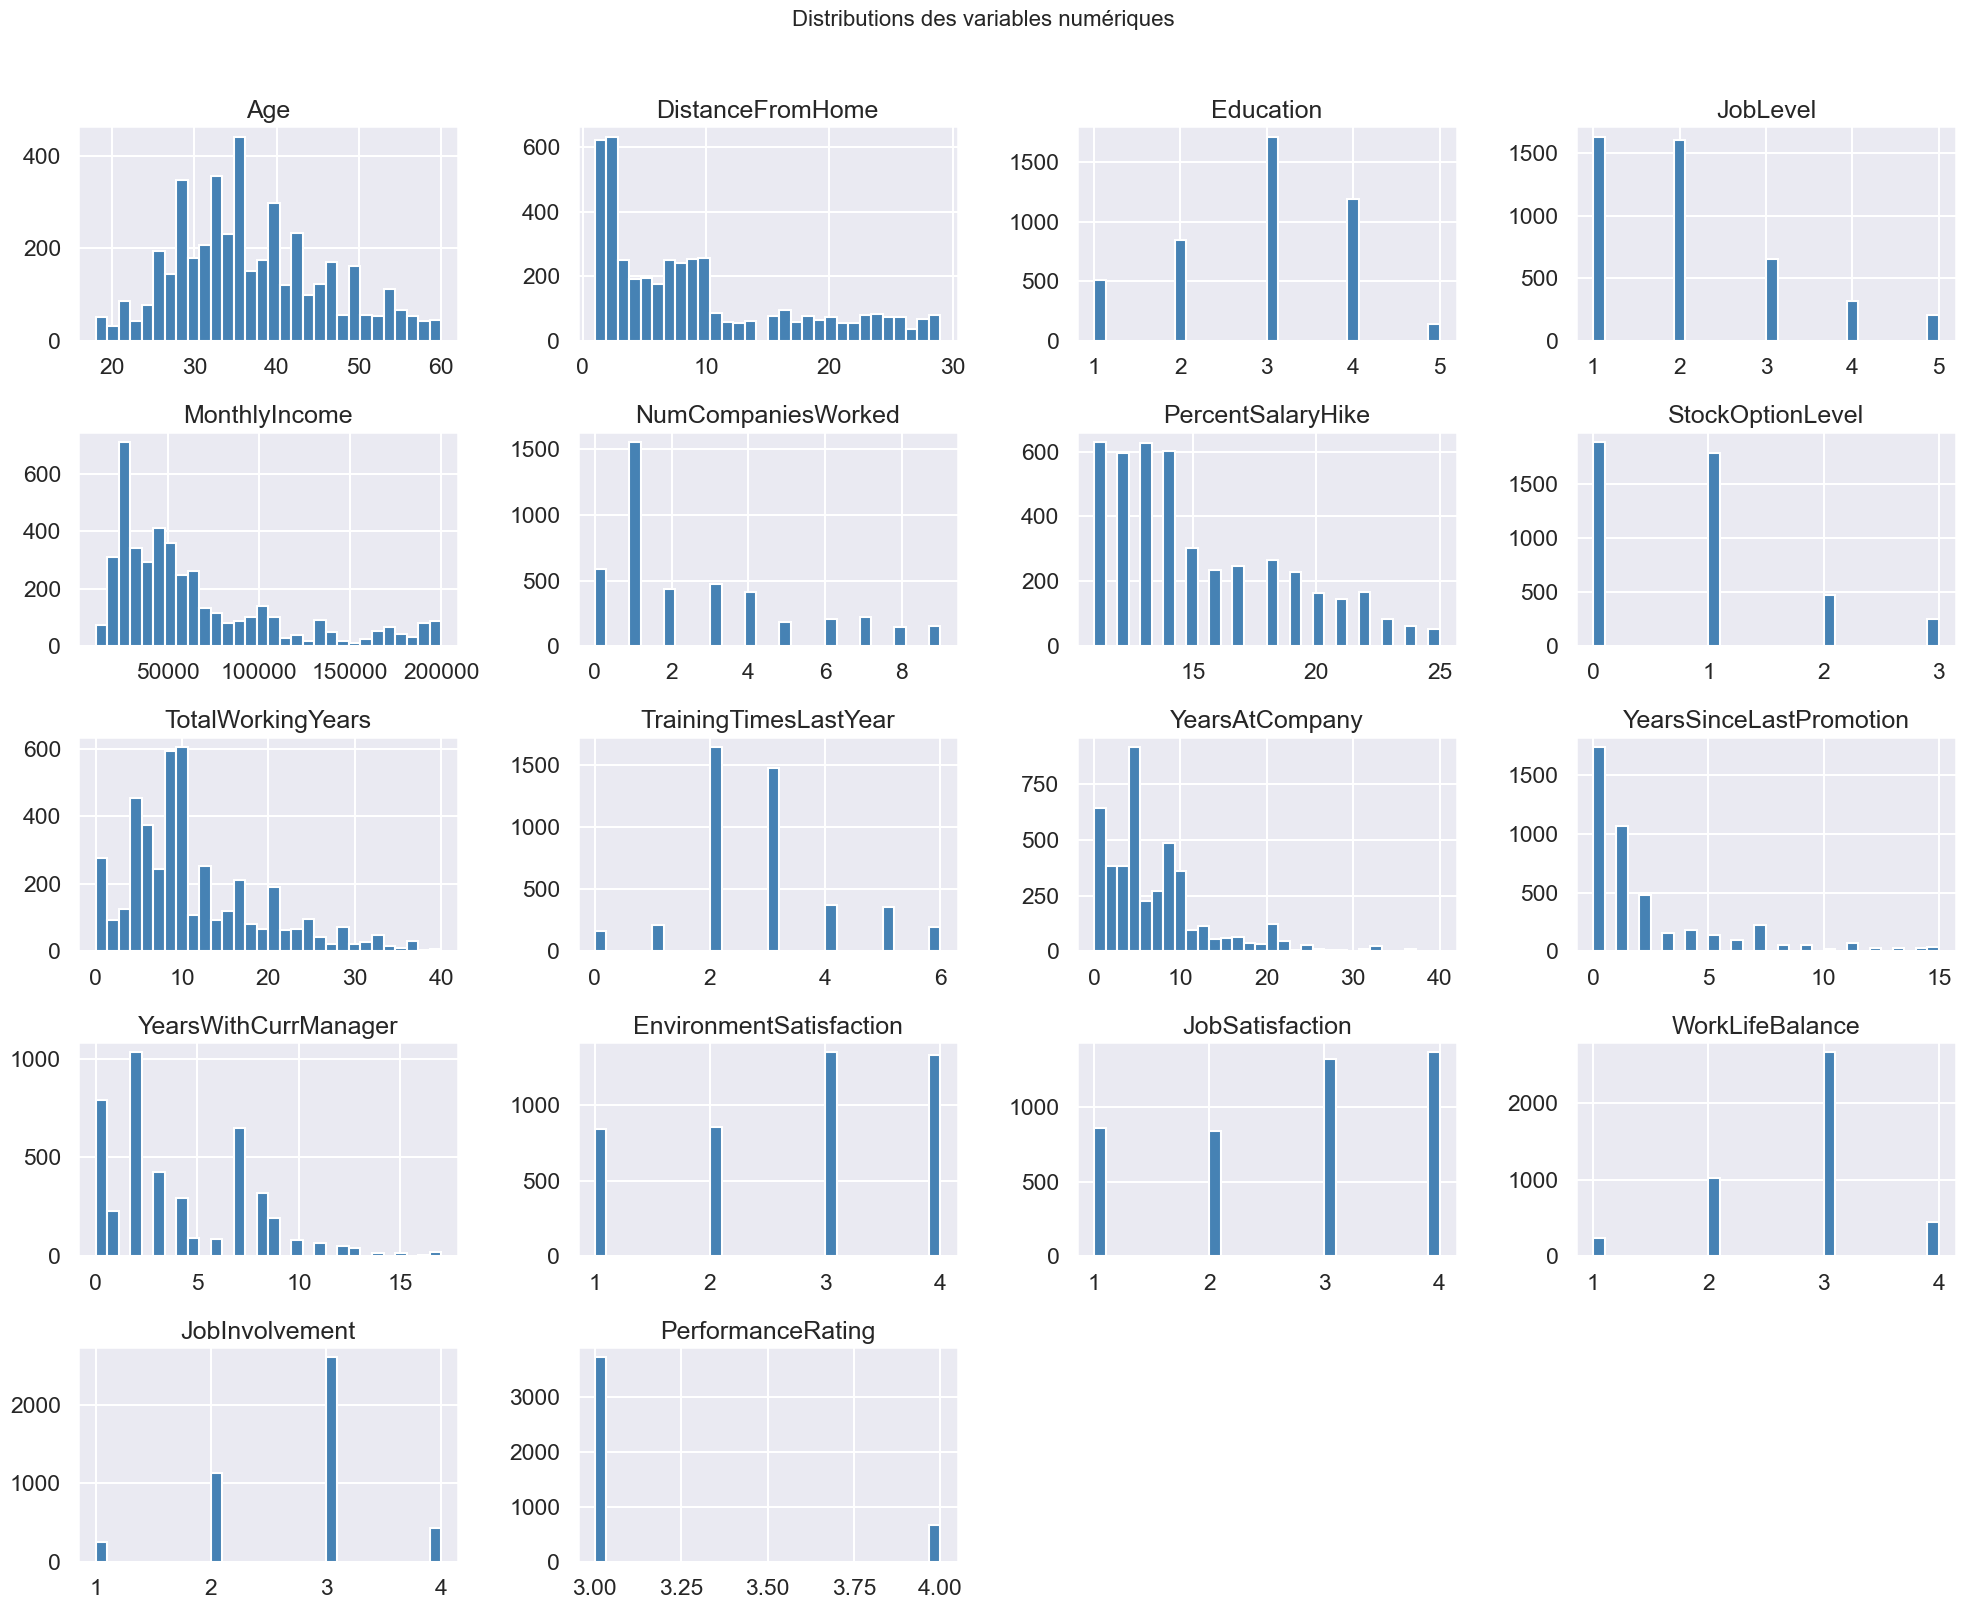

In [12]:
# Histogrammes de toutes les variables numériques
df[numerical_cols].hist(bins=30, figsize=(20, 16), color='steelblue', edgecolor='white')
plt.suptitle("Distributions des variables numériques", fontsize=16, y=1.01)
plt.tight_layout()
plt.show()

### 3.5 Analyse univariée — Variables catégorielles

In [13]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
categorical_cols.remove('Attrition')  # Variable cible, traitée séparément
print('Variables catégorielles :', categorical_cols)

Variables catégorielles : ['BusinessTravel', 'Department', 'EducationField', 'Gender', 'JobRole', 'MaritalStatus']


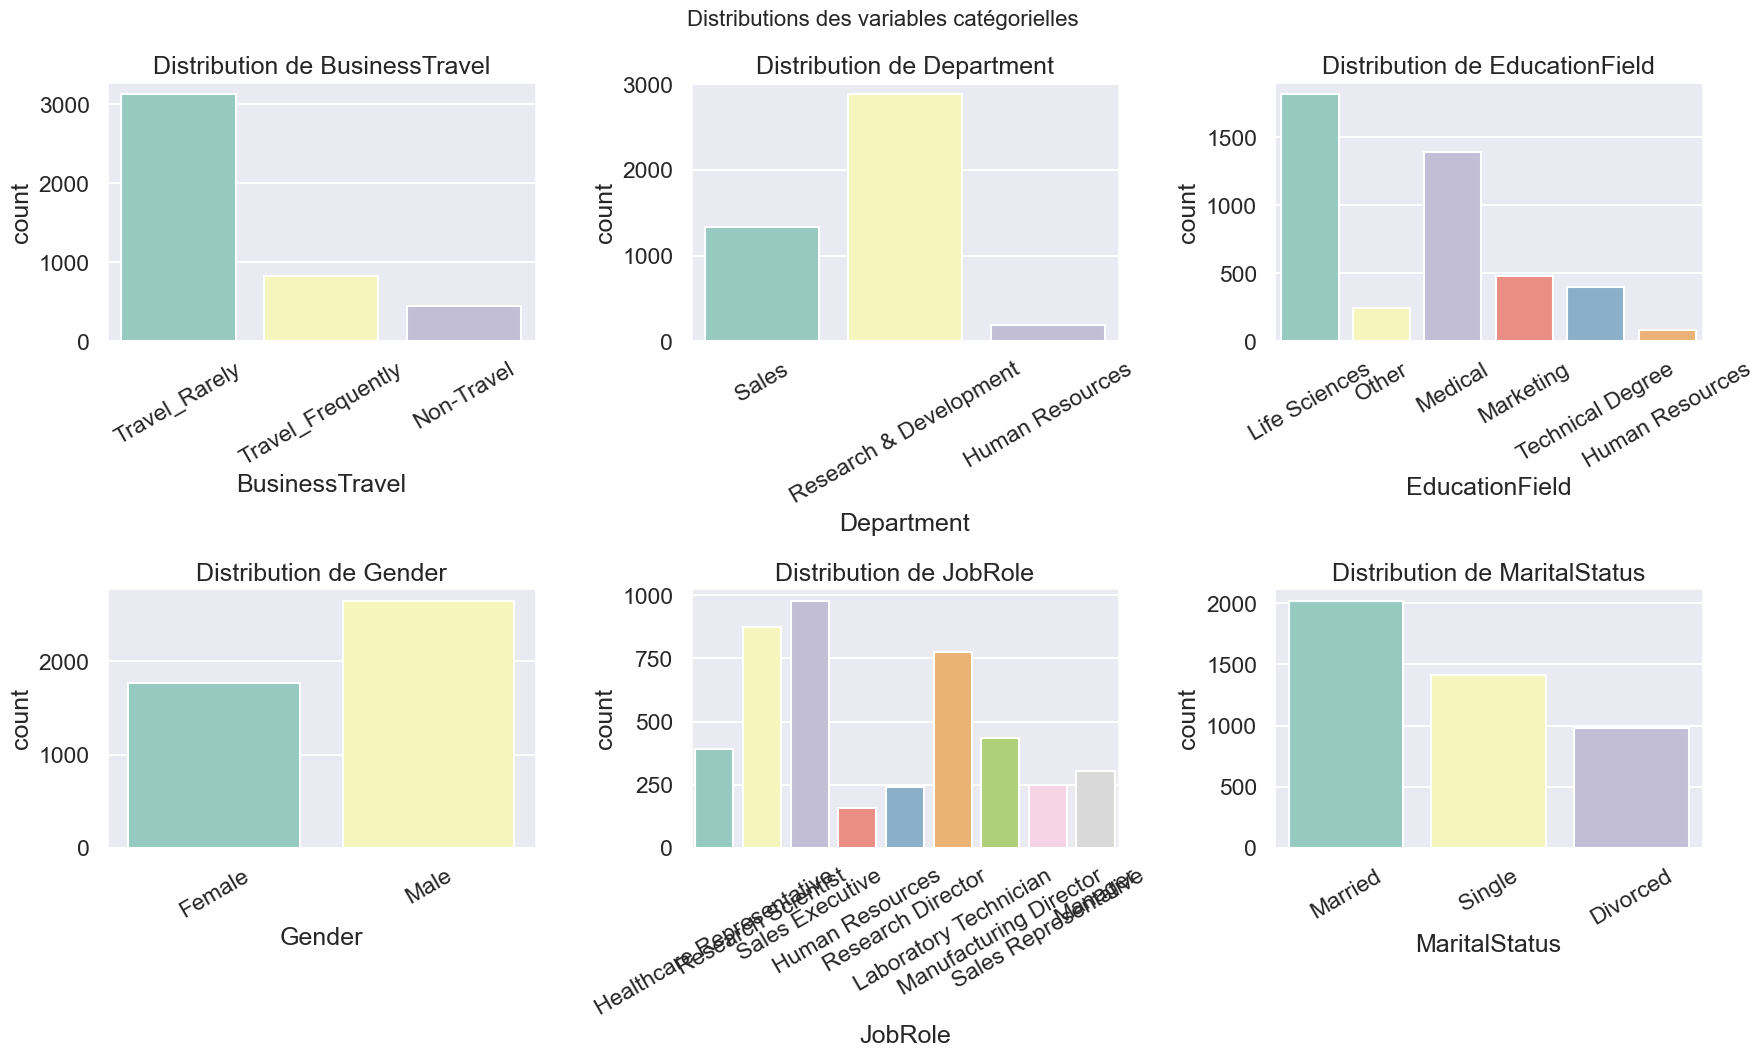

In [14]:
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        sns.countplot(x=col, data=df, ax=axes[i], palette='Set3')
        axes[i].set_title(f'Distribution de {col}')
        axes[i].tick_params(axis='x', rotation=30)

# Masquer les axes vides
for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Distributions des variables catégorielles", fontsize=16)
plt.tight_layout()
plt.show()

### 3.6 Analyse bivariée — Variables vs Attrition

On cherche les variables les plus discriminantes pour prédire le départ d'un employé.

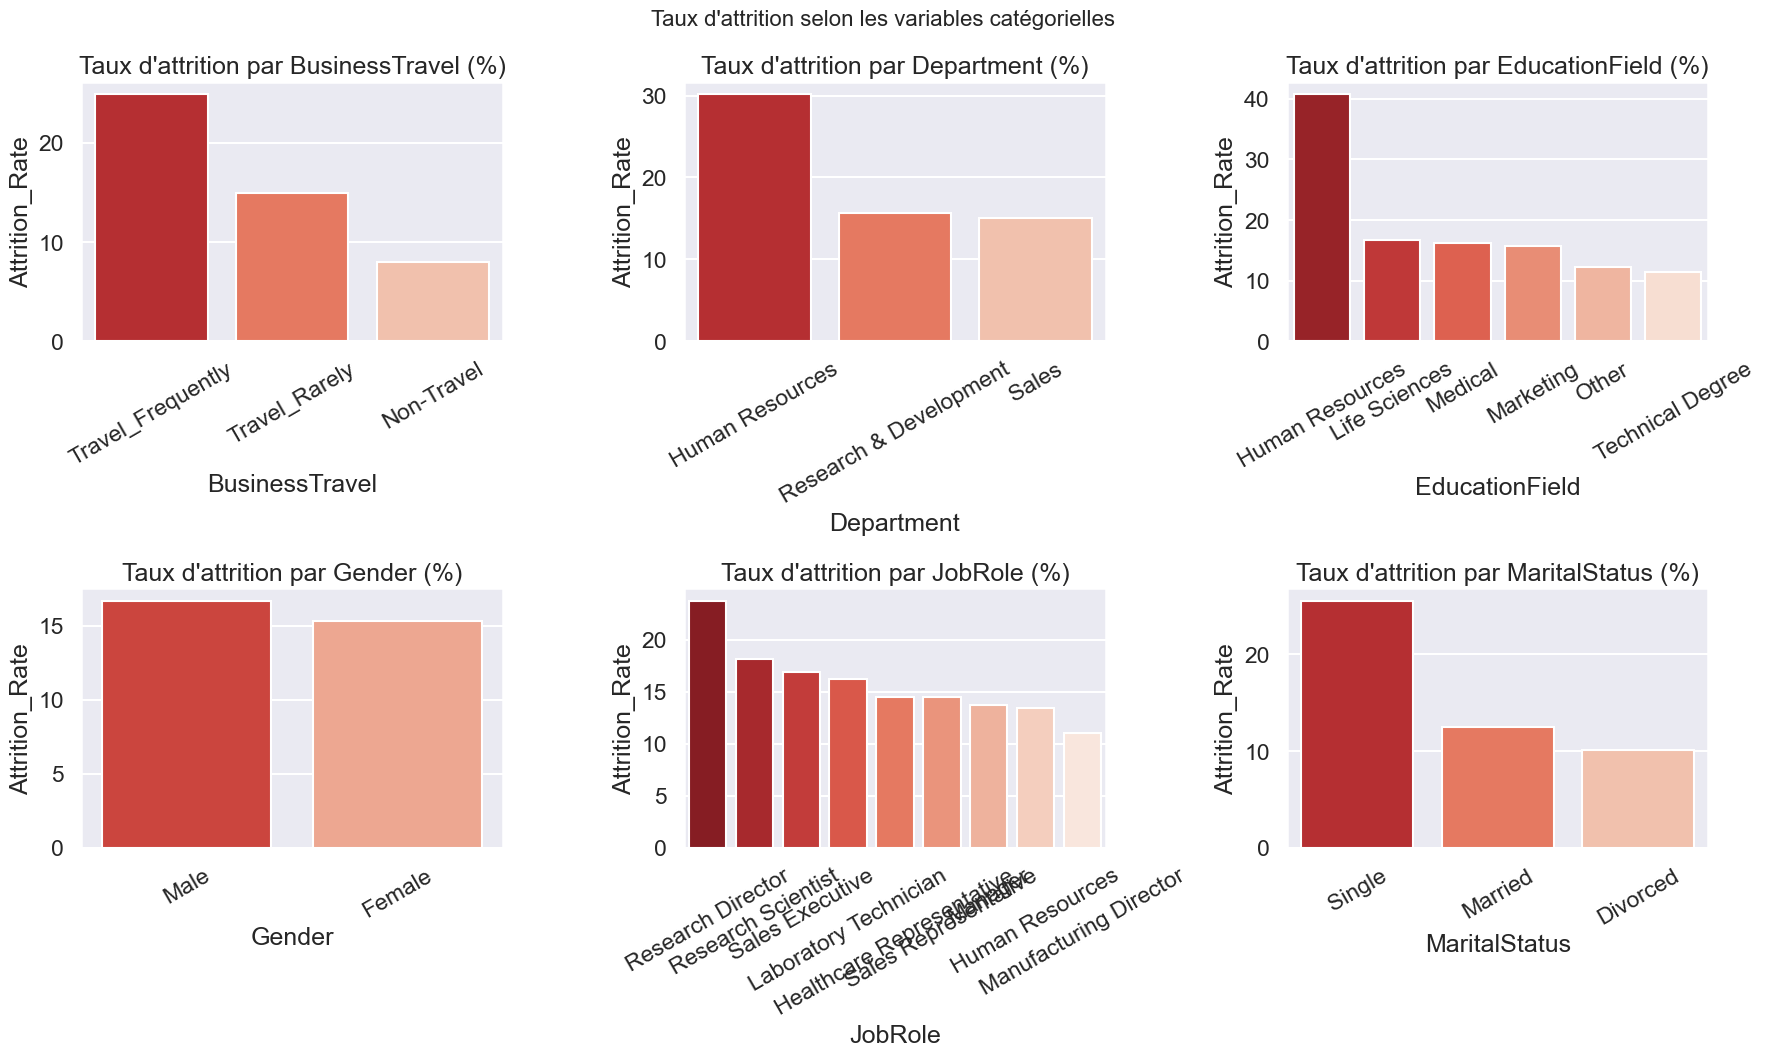

In [15]:
# Taux d'attrition par variable catégorielle
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    if i < len(axes):
        attrition_rate = df.groupby(col)['Attrition'].apply(
            lambda x: (x == 'Yes').mean() * 100
        ).reset_index()
        attrition_rate.columns = [col, 'Attrition_Rate']
        attrition_rate = attrition_rate.sort_values('Attrition_Rate', ascending=False)
        
        sns.barplot(x=col, y='Attrition_Rate', data=attrition_rate, ax=axes[i], palette='Reds_r')
        axes[i].set_title(f"Taux d'attrition par {col} (%)")
        axes[i].tick_params(axis='x', rotation=30)

for j in range(i + 1, len(axes)):
    axes[j].set_visible(False)

plt.suptitle("Taux d'attrition selon les variables catégorielles", fontsize=16)
plt.tight_layout()
plt.show()

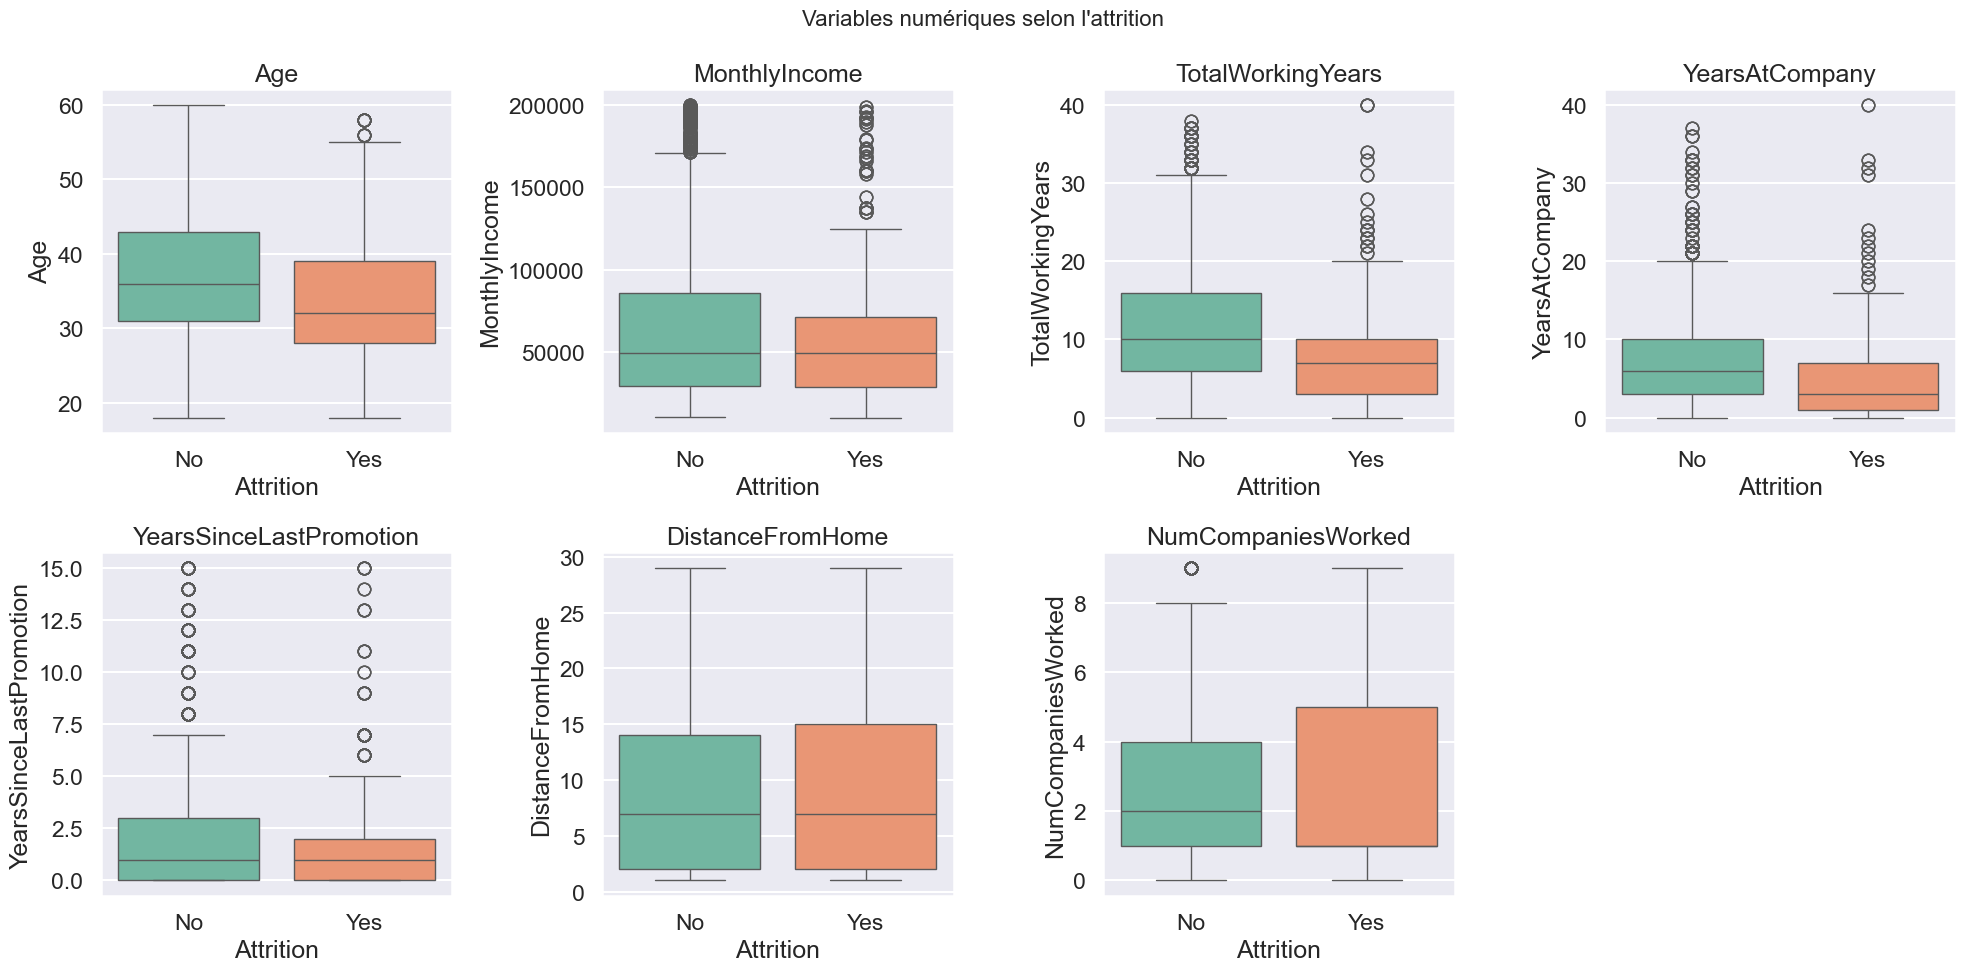

In [16]:
# Boxplots : variables numériques clés vs Attrition
key_num_vars = ['Age', 'MonthlyIncome', 'TotalWorkingYears', 'YearsAtCompany',
                'YearsSinceLastPromotion', 'DistanceFromHome', 'NumCompaniesWorked']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(key_num_vars):
    sns.boxplot(x='Attrition', y=col, data=df, ax=axes[i], palette='Set2')
    axes[i].set_title(col)

axes[-1].set_visible(False)
plt.suptitle("Variables numériques selon l'attrition", fontsize=16)
plt.tight_layout()
plt.show()

### 3.7 Matrice de corrélation

La heatmap permet d'identifier les variables fortement corrélées entre elles (risque de multicolinéarité) et celles corrélées avec la cible.

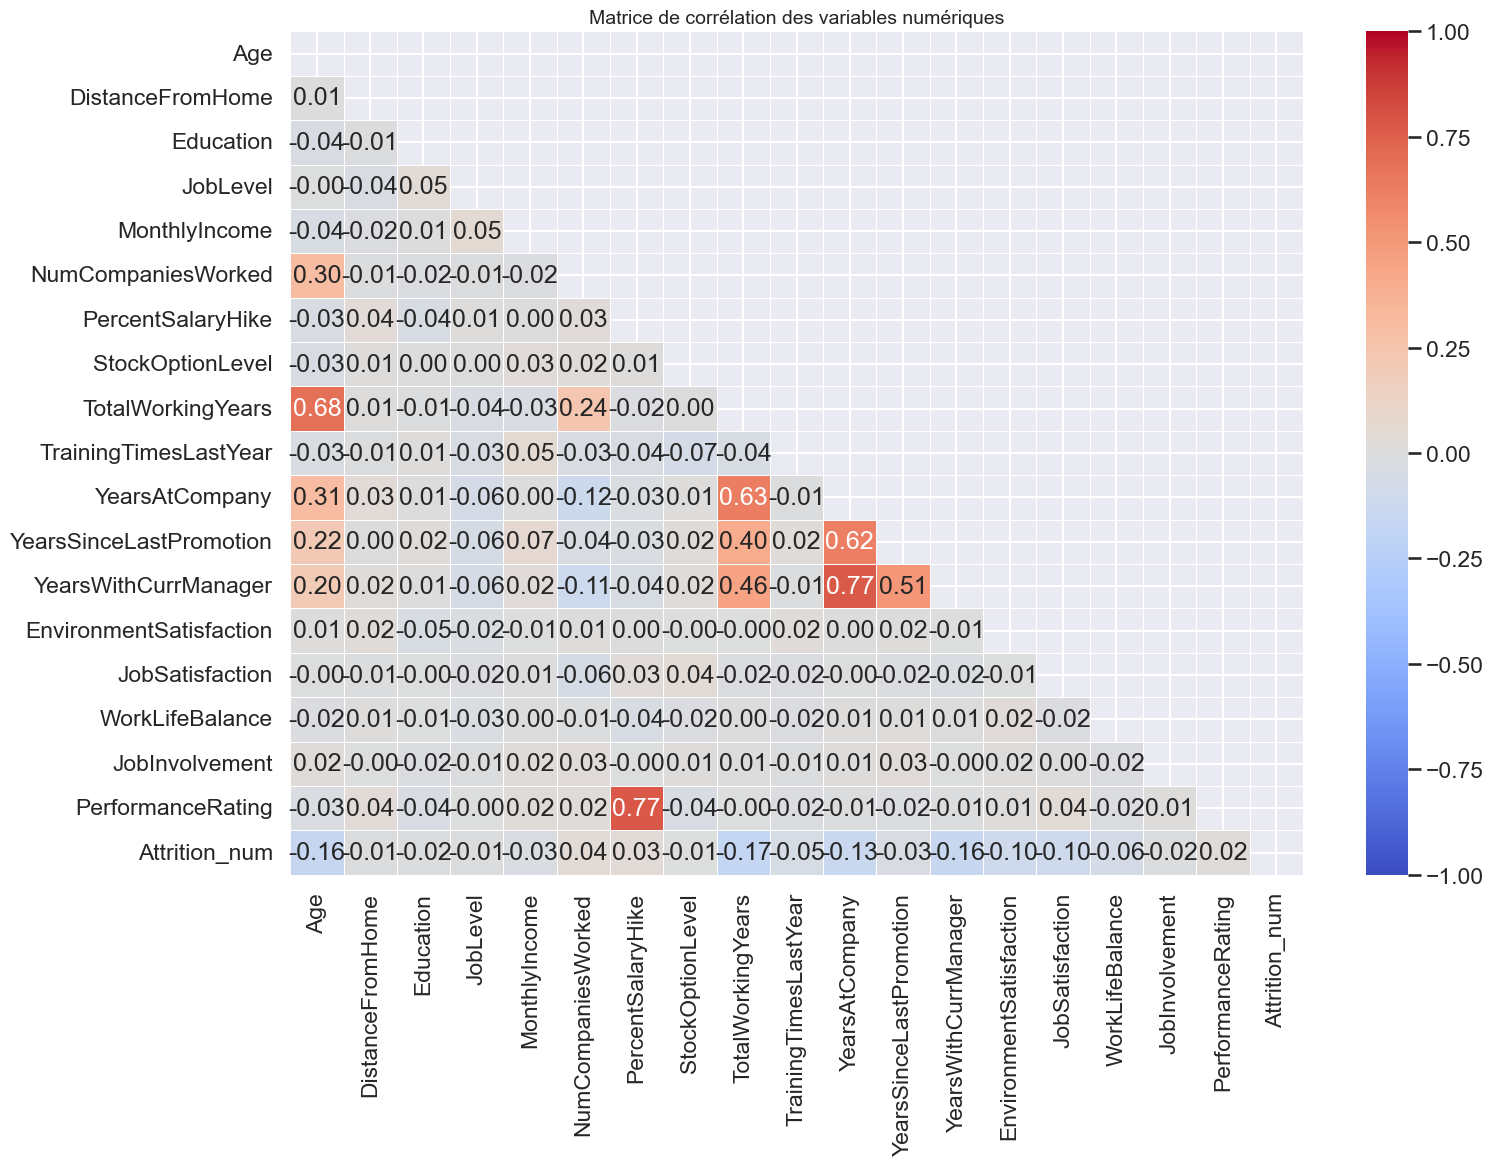


Corrélations avec l'attrition :
TotalWorkingYears         -0.17
Age                       -0.16
YearsWithCurrManager      -0.16
YearsAtCompany            -0.13
JobSatisfaction           -0.10
EnvironmentSatisfaction   -0.10
WorkLifeBalance           -0.06
TrainingTimesLastYear     -0.05
NumCompaniesWorked         0.04
YearsSinceLastPromotion   -0.03
Name: Attrition_num, dtype: float64


In [17]:
# Encodage temporaire de la cible pour la corrélation
df_corr = df.copy()
df_corr['Attrition_num'] = (df_corr['Attrition'] == 'Yes').astype(int)

corr_cols = numerical_cols + ['Attrition_num']
corr_matrix = df_corr[corr_cols].corr()

plt.figure(figsize=(16, 12))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            mask=mask, vmin=-1, vmax=1, linewidths=0.5)
plt.title('Matrice de corrélation des variables numériques', fontsize=14)
plt.tight_layout()
plt.show()

# Top corrélations avec l'attrition
print("\nCorrélations avec l'attrition :")
print(corr_matrix['Attrition_num'].drop('Attrition_num').sort_values(key=abs, ascending=False).head(10))

---
## Partie 4 — Ingénierie des caractéristiques : horaires de travail

Les fichiers `in_time.csv` et `out_time.csv` contiennent les horaires d'arrivée et de départ de chaque employé pour chaque jour ouvré de 2015.

On va extraire les variables suivantes pour chaque employé :
- `avg_hours_worked` : durée moyenne journalière de présence
- `avg_arrival_hour` : heure d'arrivée moyenne
- `absence_rate` : taux de jours non badgés (absences ou congés)

Ces indicateurs peuvent être des signaux importants de désengagement.

In [18]:
# Conversion en datetime
in_dt  = in_time.apply(pd.to_datetime, errors='coerce')
out_dt = out_time.apply(pd.to_datetime, errors='coerce')

# Durée de présence en heures pour chaque jour
hours_worked = (out_dt - in_dt).apply(lambda s: s.dt.total_seconds() / 3600)

# Nombre total de jours ouvrés (colonnes du fichier)
total_days = in_dt.shape[1]

# Variables agrégées par employé
time_features = pd.DataFrame(index=in_time.index)
time_features.index.name = 'EmployeeID'

time_features['avg_hours_worked'] = hours_worked.mean(axis=1, skipna=True)
time_features['avg_arrival_hour'] = in_dt.apply(
    lambda row: row.dropna().apply(lambda x: x.hour + x.minute/60).mean(), axis=1
)
# Taux d'absence : proportion de jours sans badge d'entrée
time_features['absence_rate'] = in_dt.isnull().sum(axis=1) / total_days

time_features = time_features.reset_index()
print(time_features.shape)
time_features.head()

(4410, 4)


,EmployeeID,avg_hours_worked,avg_arrival_hour,absence_rate
0,1,7.37,9.99,0.11
1,2,7.72,9.98,0.10
2,3,7.01,10.02,0.07
3,4,7.19,9.97,0.10
4,5,8.01,9.99,0.06


In [19]:
# Fusion avec le dataframe principal
# Note : general_data.csv utilise 'EmployeeID' (avec ID)
df = general.merge(emp_survey, on='EmployeeID', how='left')
df = df.merge(mgr_survey,  on='EmployeeID', how='left')
df = df.merge(time_features, on='EmployeeID', how='left')

# Suppression des colonnes redondantes
df.drop(columns=['EmployeeCount', 'StandardHours', 'Over18', 'EmployeeID'], inplace=True)

print('Dimensions finales :', df.shape)
print('Nouvelles features :', ['avg_hours_worked', 'avg_arrival_hour', 'absence_rate'])

Dimensions finales : (4410, 28)
Nouvelles features : ['avg_hours_worked', 'avg_arrival_hour', 'absence_rate']


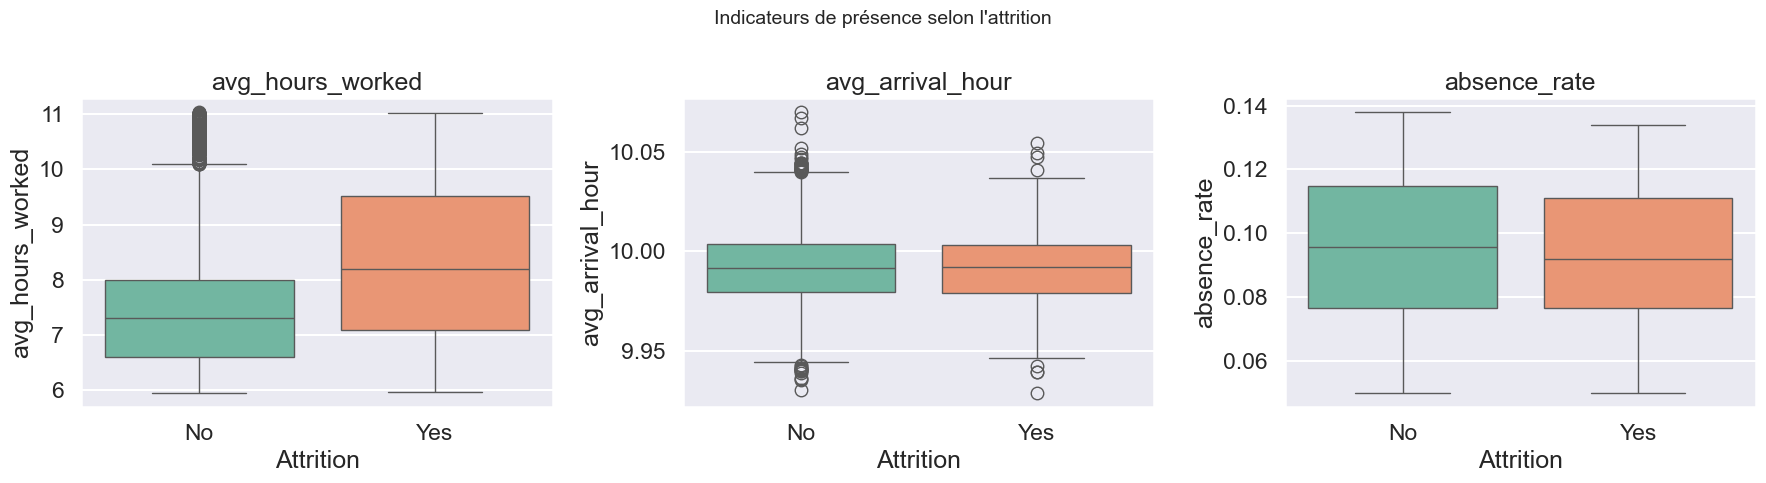

In [20]:
# Visualisation : horaires de travail et attrition
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, ['avg_hours_worked', 'avg_arrival_hour', 'absence_rate']):
    sns.boxplot(x='Attrition', y=col, data=df, palette='Set2', ax=ax)
    ax.set_title(col)

plt.suptitle("Indicateurs de présence selon l'attrition", fontsize=14)
plt.tight_layout()
plt.show()

---
## Partie 5 — Préparation des données pour le Machine Learning

Étapes :
1. **Gestion des valeurs manquantes** : imputation par la médiane (numériques) et le mode (catégorielles)
2. **Encodage des variables catégorielles** : One-Hot Encoding
3. **Encodage de la cible** : `Yes` → 1, `No` → 0
4. **Normalisation** : StandardScaler pour les variables numériques
5. **Split train / test** : 70% / 30%

### 5.1 Imputation des valeurs manquantes

In [21]:
print("Valeurs manquantes avant imputation :")
print(df.isnull().sum()[df.isnull().sum() > 0])

Valeurs manquantes avant imputation :
NumCompaniesWorked         19
TotalWorkingYears           9
EnvironmentSatisfaction    25
JobSatisfaction            20
WorkLifeBalance            38
dtype: int64


In [22]:
# Séparation des colonnes par type
target_col     = 'Attrition'
cat_cols       = df.drop(columns=[target_col]).select_dtypes(include='object').columns.tolist()
num_cols       = df.drop(columns=[target_col]).select_dtypes(include=['int64', 'float64']).columns.tolist()

# Imputation numérique : médiane
num_imputer = SimpleImputer(strategy='median')
df[num_cols] = num_imputer.fit_transform(df[num_cols])

# Imputation catégorielle : mode
cat_imputer = SimpleImputer(strategy='most_frequent')
df[cat_cols] = cat_imputer.fit_transform(df[cat_cols])

print("Valeurs manquantes après imputation :", df.isnull().sum().sum())

Valeurs manquantes après imputation : 0


### 5.2 Encodage des variables catégorielles et de la cible

In [23]:
# Encodage de la cible
y = (df[target_col] == 'Yes').astype(int)
print("Distribution de la cible :\n", y.value_counts())

# One-Hot Encoding des variables catégorielles
df_features = df.drop(columns=[target_col])
df_encoded  = pd.get_dummies(df_features, columns=cat_cols, drop_first=True)

print(f"\nNombre de features après encodage : {df_encoded.shape[1]}")
df_encoded.head(3)

Distribution de la cible :
 Attrition
0    3699
1     711
Name: count, dtype: int64

Nombre de features après encodage : 41


,Age,DistanceFromHome,Education,JobLevel,MonthlyIncome,NumCompaniesWorked,PercentSalaryHike,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,YearsAtCompany,YearsSinceLastPromotion,YearsWithCurrManager,EnvironmentSatisfaction,JobSatisfaction,WorkLifeBalance,JobInvolvement,PerformanceRating,avg_hours_worked,avg_arrival_hour,absence_rate,BusinessTravel_Travel_Frequently,BusinessTravel_Travel_Rarely,Department_Research & Development,Department_Sales,EducationField_Life Sciences,EducationField_Marketing,EducationField_Medical,EducationField_Other,EducationField_Technical Degree,Gender_Male,JobRole_Human Resources,JobRole_Laboratory Technician,JobRole_Manager,JobRole_Manufacturing Director,JobRole_Research Director,JobRole_Research Scientist,JobRole_Sales Executive,JobRole_Sales Representative,MaritalStatus_Married,MaritalStatus_Single
0,51.0,6.0,2.0,1.0,131160.0,1.0,11.0,0.0,1.0,6.0,1.0,0.0,0.0,3.0,4.0,2.0,3.0,3.0,7.37,9.99,0.11,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False
1,31.0,10.0,1.0,1.0,41890.0,0.0,23.0,1.0,6.0,3.0,5.0,1.0,4.0,3.0,2.0,4.0,2.0,4.0,7.72,9.98,0.10,True,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,True
2,32.0,17.0,4.0,4.0,193280.0,1.0,15.0,3.0,5.0,2.0,5.0,0.0,3.0,2.0,2.0,1.0,3.0,3.0,7.01,10.02,0.07,True,False,True,False,False,False,False,True,False,True,False,False,False,False,False,False,True,False,True,False


### 5.3 Normalisation et split train/test

In [24]:
# Normalisation
scaler = StandardScaler()
X = pd.DataFrame(
    scaler.fit_transform(df_encoded),
    columns=df_encoded.columns
)

# Split stratifié (70% train, 30% test) — stratifié pour conserver le ratio d'attrition
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

print(f"Train : {X_train.shape[0]} exemples")
print(f"Test  : {X_test.shape[0]} exemples")
print(f"Taux d'attrition train : {y_train.mean()*100:.1f}%")
print(f"Taux d'attrition test  : {y_test.mean()*100:.1f}%")

Train : 3087 exemples
Test  : 1323 exemples
Taux d'attrition train : 16.1%
Taux d'attrition test  : 16.1%


---
## Partie 6 — Entraînement des modèles de classification

On entraîne 6 modèles vus en cours :
1. **Régression Logistique** — modèle linéaire de référence
2. **Perceptron** — réseau de neurones monocouche
3. **SVM (Support Vector Machine)** — maximum-margin classifier
4. **Naive Bayes** — modèle probabiliste
5. **Arbre de Décision** — modèle interprétable
6. **Random Forest** — méthode d'ensemble, robuste au surapprentissage

### 6.1 Régression Logistique

La régression logistique modélise la probabilité d'appartenir à la classe 1 via une fonction sigmoïde appliquée à une combinaison linéaire des features. C'est le modèle de référence (baseline) pour la classification binaire.

=== Régression Logistique ===
              precision    recall  f1-score   support

          No       0.87      0.97      0.92      1110
         Yes       0.63      0.27      0.38       213

    accuracy                           0.86      1323
   macro avg       0.75      0.62      0.65      1323
weighted avg       0.83      0.86      0.83      1323



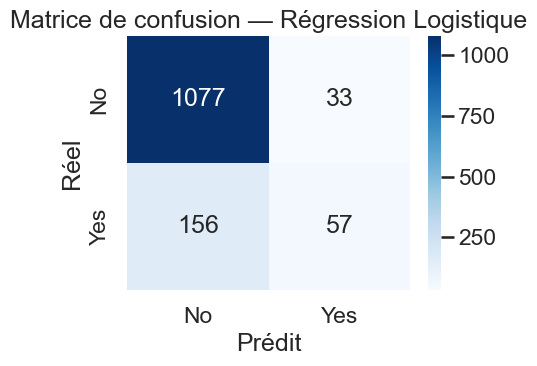

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

lr_model = LogisticRegression(max_iter=1000, random_state=42)
lr_model.fit(X_train, y_train)
y_pred_lr = lr_model.predict(X_test)

print("=== Régression Logistique ===")
print(classification_report(y_test, y_pred_lr, target_names=['No', 'Yes']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_lr), annot=True, fmt='d',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], cmap='Blues')
plt.title('Matrice de confusion — Régression Logistique')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

### 6.2 Perceptron

Le Perceptron est un classificateur linéaire à une couche. Il apprend en mettant à jour les poids lors de chaque erreur de classification. Il ne produit pas de probabilités.

=== Perceptron ===
              precision    recall  f1-score   support

          No       0.87      0.87      0.87      1110
         Yes       0.33      0.32      0.32       213

    accuracy                           0.78      1323
   macro avg       0.60      0.60      0.60      1323
weighted avg       0.78      0.78      0.78      1323



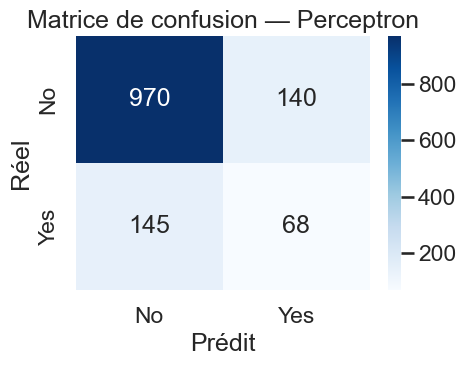

In [26]:
from sklearn.linear_model import Perceptron

perceptron = Perceptron(random_state=42, max_iter=1000)
perceptron.fit(X_train, y_train)
y_pred_perc = perceptron.predict(X_test)

print("=== Perceptron ===")
print(classification_report(y_test, y_pred_perc, target_names=['No', 'Yes']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_perc), annot=True, fmt='d',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], cmap='Blues')
plt.title('Matrice de confusion — Perceptron')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

### 6.3 Support Vector Machine (SVM)

Le SVM cherche l'hyperplan qui maximise la marge entre les deux classes. Le paramètre `probability=True` permet d'obtenir des scores de probabilité pour la courbe ROC.

=== SVM ===
              precision    recall  f1-score   support

          No       0.90      0.99      0.94      1110
         Yes       0.86      0.43      0.57       213

    accuracy                           0.90      1323
   macro avg       0.88      0.71      0.76      1323
weighted avg       0.89      0.90      0.88      1323



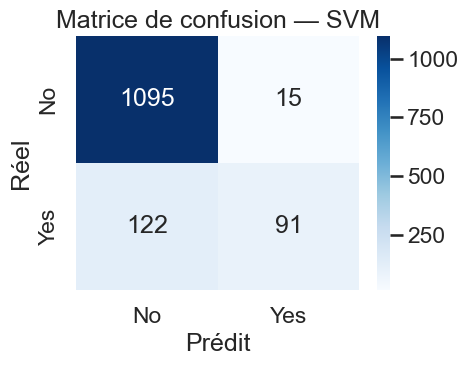

In [27]:
from sklearn.svm import SVC

svm_model = SVC(probability=True, random_state=42)
svm_model.fit(X_train, y_train)
y_pred_svm = svm_model.predict(X_test)

print("=== SVM ===")
print(classification_report(y_test, y_pred_svm, target_names=['No', 'Yes']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_svm), annot=True, fmt='d',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], cmap='Blues')
plt.title('Matrice de confusion — SVM')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

### 6.4 Naive Bayes

Naive Bayes applique le théorème de Bayes en supposant l'indépendance conditionnelle entre les features. Rapide et efficace même avec peu de données.

=== Naive Bayes ===
              precision    recall  f1-score   support

          No       0.90      0.87      0.88      1110
         Yes       0.42      0.48      0.45       213

    accuracy                           0.81      1323
   macro avg       0.66      0.68      0.67      1323
weighted avg       0.82      0.81      0.81      1323



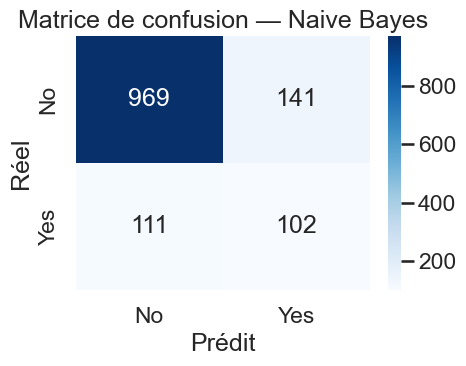

In [28]:
from sklearn.naive_bayes import GaussianNB

nb_model = GaussianNB()
nb_model.fit(X_train, y_train)
y_pred_nb = nb_model.predict(X_test)

print("=== Naive Bayes ===")
print(classification_report(y_test, y_pred_nb, target_names=['No', 'Yes']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_nb), annot=True, fmt='d',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], cmap='Blues')
plt.title('Matrice de confusion — Naive Bayes')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

### 6.5 Arbre de Décision

L'arbre de décision divise récursivement l'espace des features selon des règles de seuil pour minimiser l'impureté (Gini). Très interprétable, mais sujet au surapprentissage.

=== Arbre de Décision ===
              precision    recall  f1-score   support

          No       0.97      0.97      0.97      1110
         Yes       0.86      0.85      0.86       213

    accuracy                           0.95      1323
   macro avg       0.92      0.91      0.91      1323
weighted avg       0.95      0.95      0.95      1323



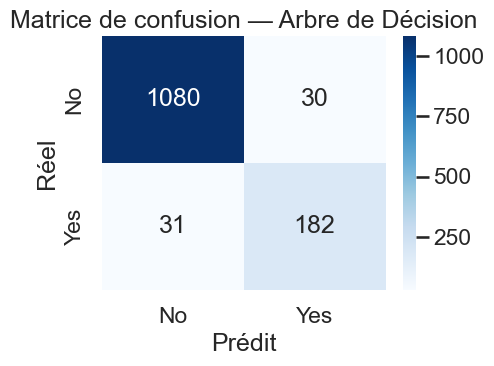

In [29]:
from sklearn.tree import DecisionTreeClassifier

tree_model = DecisionTreeClassifier(random_state=42)
tree_model.fit(X_train, y_train)
y_pred_tree = tree_model.predict(X_test)

print("=== Arbre de Décision ===")
print(classification_report(y_test, y_pred_tree, target_names=['No', 'Yes']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_tree), annot=True, fmt='d',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], cmap='Blues')
plt.title('Matrice de confusion — Arbre de Décision')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

### 6.6 Random Forest

La forêt aléatoire est un ensemble de N arbres de décision entraînés sur des sous-échantillons Bootstrap. La prédiction finale est le vote majoritaire. Elle réduit le surapprentissage grâce à la diversité des arbres.

=== Random Forest ===
              precision    recall  f1-score   support

          No       0.98      1.00      0.99      1110
         Yes       0.98      0.88      0.93       213

    accuracy                           0.98      1323
   macro avg       0.98      0.94      0.96      1323
weighted avg       0.98      0.98      0.98      1323



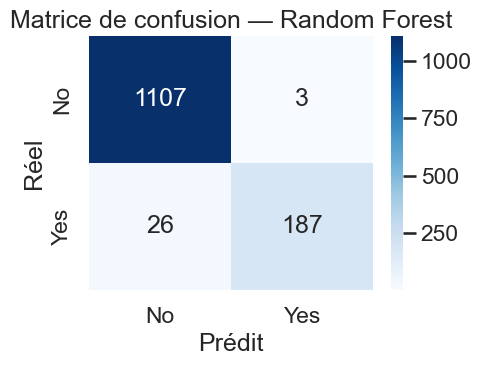

In [30]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
y_pred_rf = rf_model.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, y_pred_rf, target_names=['No', 'Yes']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_rf), annot=True, fmt='d',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], cmap='Blues')
plt.title('Matrice de confusion — Random Forest')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

---
## Partie 7 — Comparaison et évaluation des modèles

On compare tous les modèles sur les métriques suivantes :
- **Precision** : parmi les prédits "Yes", combien sont vrais ?
- **Recall** : parmi les vrais "Yes", combien sont détectés ? *(métrique critique ici)*
- **F1-Score** : moyenne harmonique de precision et recall
- **ROC-AUC** : capacité discriminante globale du modèle

> **Pourquoi l'Accuracy est exclue du graphique comparatif ?**
> Avec ~85% de "No Attrition" dans les données, un modèle qui prédit *toujours* "No" obtiendrait 85% d'accuracy sans jamais détecter un seul départ. L'accuracy est donc **trompeuse sur des données déséquilibrées** : elle flatte les modèles qui ignorent la classe minoritaire. On lui préfère le **F1-Score** (équilibre précision/rappel) et le **ROC-AUC** (capacité discriminante indépendante du seuil).

> **Note :** Pour HumanForYou, le **recall** est la métrique prioritaire. Il vaut mieux signaler un faux positif (alerter sur un employé qui ne partira pas) que manquer un départ réel (faux négatif), car le coût de remplacement est élevé.


In [31]:
import time

models = {
    'Logistic Regression' : lr_model,
    'Perceptron'          : perceptron,
    'SVM'                 : svm_model,
    'Naive Bayes'         : nb_model,
    'Decision Tree'       : tree_model,
    'Random Forest'       : rf_model,
}

predictions = {
    'Logistic Regression' : y_pred_lr,
    'Perceptron'          : y_pred_perc,
    'SVM'                 : y_pred_svm,
    'Naive Bayes'         : y_pred_nb,
    'Decision Tree'       : y_pred_tree,
    'Random Forest'       : y_pred_rf,
}

results = []
for name, y_pred in predictions.items():
    model = models[name]
    auc = roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]) \
          if hasattr(model, 'predict_proba') else None
    results.append({
        'Modèle'    : name,
        'Accuracy'  : round(accuracy_score(y_test, y_pred), 3),
        'Precision' : round(precision_score(y_test, y_pred, zero_division=0), 3),
        'Recall'    : round(recall_score(y_test, y_pred), 3),
        'F1-Score'  : round(f1_score(y_test, y_pred, zero_division=0), 3),
        'ROC-AUC'   : round(auc, 3) if auc else 'N/A',
    })

results_df = pd.DataFrame(results).set_index('Modèle')
results_df.sort_values('F1-Score', ascending=False)

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Modèle,,,,,
Random Forest,0.98,0.98,0.88,0.93,0.98
Decision Tree,0.95,0.86,0.85,0.86,0.91
SVM,0.90,0.86,0.43,0.57,0.93
Naive Bayes,0.81,0.42,0.48,0.45,0.75
Logistic Regression,0.86,0.63,0.27,0.38,0.8
Perceptron,0.79,0.33,0.32,0.32,N/A


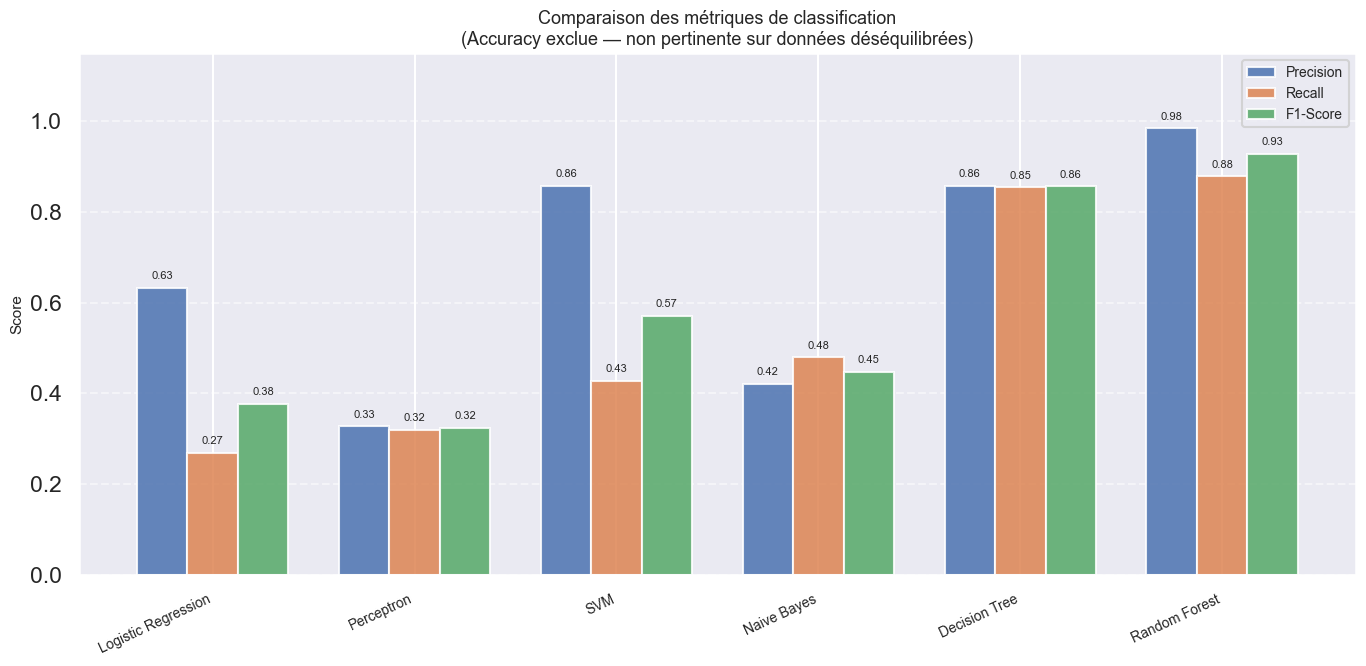

In [32]:
# Visualisation comparative (sans Accuracy — non pertinente sur données déséquilibrées)
metrics_to_plot = ['Precision', 'Recall', 'F1-Score']
plot_df = results_df[metrics_to_plot].copy()

x = np.arange(len(plot_df))
width = 0.25
colors = ['#4C72B0', '#DD8452', '#55A868']

fig, ax = plt.subplots(figsize=(14, 7))
for i, (metric, color) in enumerate(zip(metrics_to_plot, colors)):
    bars = ax.bar(x + (i - 1) * width, plot_df[metric], width, label=metric,
                  color=color, alpha=0.85, edgecolor='white')
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h + 0.015,
                f'{h:.2f}', ha='center', va='bottom', fontsize=8)

ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=25, ha='right', fontsize=10)
ax.set_ylim(0, 1.15)
ax.set_ylabel('Score', fontsize=11)
ax.set_title('Comparaison des métriques de classification\n(Accuracy exclue — non pertinente sur données déséquilibrées)',
             fontsize=13)
ax.legend(loc='upper right', fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


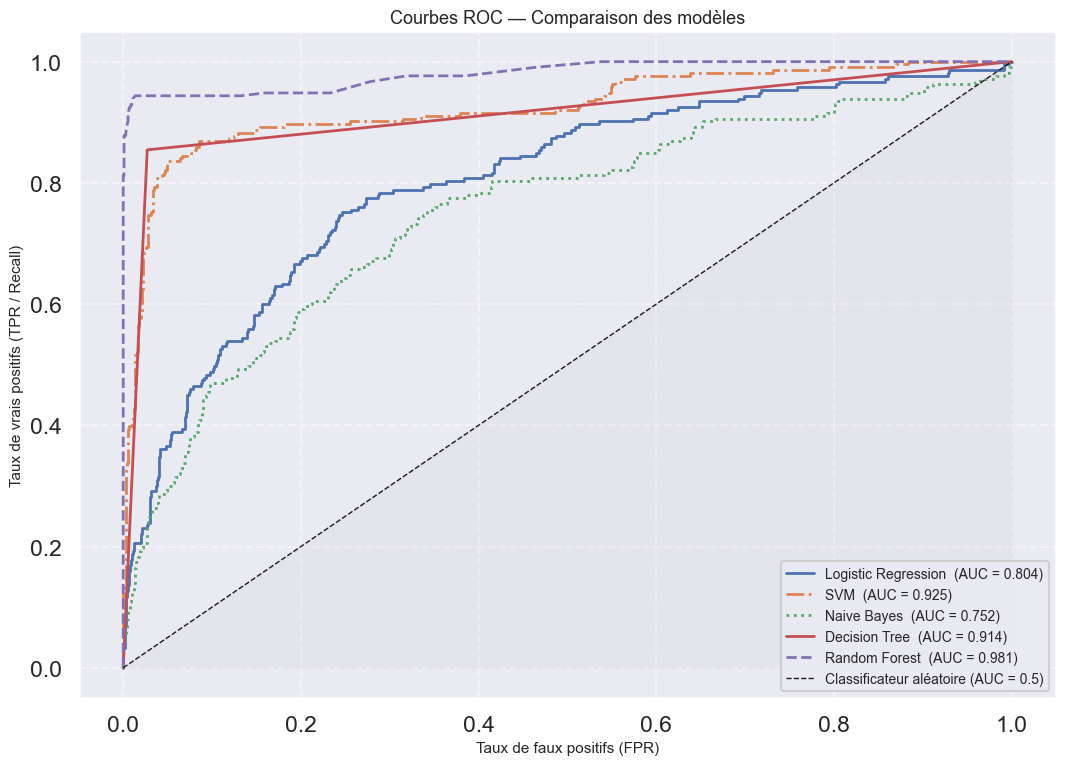

In [33]:
# Courbes ROC comparatives
fig, ax = plt.subplots(figsize=(11, 8))

line_styles = ['-', '--', '-.', ':', '-', '--']
for (name, model), ls in zip(models.items(), line_styles):
    if hasattr(model, 'predict_proba'):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        ax.plot(fpr, tpr, lw=2, linestyle=ls, label=f'{name}  (AUC = {auc:.3f})')

ax.plot([0, 1], [0, 1], 'k--', lw=1, label='Classificateur aléatoire (AUC = 0.5)')
ax.fill_between([0, 1], [0, 1], alpha=0.05, color='gray')
ax.set_xlabel('Taux de faux positifs (FPR)', fontsize=11)
ax.set_ylabel('Taux de vrais positifs (TPR / Recall)', fontsize=11)
ax.set_title('Courbes ROC — Comparaison des modèles', fontsize=13)
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.xaxis.grid(True, linestyle='--', alpha=0.4)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


#### Interprétation de l'AUC (Area Under the Curve)

L'**AUC** mesure la surface sous la courbe ROC. Elle représente la **probabilité que le modèle classe correctement une paire (employé qui part, employé qui reste)** choisie au hasard.

| Valeur AUC | Interprétation |
|:---:|:---|
| 1.0 | Modèle parfait |
| 0.9 – 1.0 | Excellent |
| 0.8 – 0.9 | Très bon |
| 0.7 – 0.8 | Acceptable |
| 0.5 | Aucune discrimination (tirage aléatoire) |

> **Avantage clé de l'AUC** : contrairement à l'accuracy, elle est **indépendante du seuil de décision** et robuste au déséquilibre des classes. Elle reste pertinente même avec 85% d'exemples négatifs.


In [34]:
# Validation croisée (10 folds) — F1-Score médiane
print('Validation croisée (10 folds) — F1-Score (médiane) :')
print('-' * 50)

for name, model in models.items():
    cv_scores = cross_val_score(model, X, y, cv=10, scoring='f1', n_jobs=-1)
    print(f'{name:<22} : médiane={np.median(cv_scores):.3f}  std={cv_scores.std():.3f}')


Validation croisée (10 folds) — F1-Score (médiane) :
--------------------------------------------------
Logistic Regression    : médiane=0.347  std=0.052
Perceptron             : médiane=0.292  std=0.043
SVM                    : médiane=0.741  std=0.039
Naive Bayes            : médiane=0.445  std=0.052
Decision Tree          : médiane=0.971  std=0.022
Random Forest          : médiane=1.000  std=0.005


---
## Partie 7.5 — Validation croisée K-Fold stratéfiée

La validation croisée K-Fold divise les données en `k` plis (ici 10). À chaque itération, un pli sert de jeu de validation et les k-1 autres d'entraînement. On utilise **StratifiedKFold** pour s'assurer que chaque pli respecte le même ratio d'attrition (~15%) — indispensable avec des données déséquilibrées.

Le paramètre `return_train_score=True` est crucial : il permet de comparer le score sur les données d'entraînement vs de validation pour **détecter le surapprentissage**.

In [35]:
from sklearn.model_selection import StratifiedKFold, cross_validate

skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

models_cv = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Perceptron'         : Perceptron(random_state=42, max_iter=1000),
    'SVM'                : SVC(probability=True, random_state=42),
    'Naive Bayes'        : GaussianNB(),
    'Decision Tree'      : DecisionTreeClassifier(random_state=42),
    'Random Forest'      : RandomForestClassifier(n_estimators=100, random_state=42),
}

cv_results = {}
for name, model in models_cv.items():
    scores = cross_validate(
        model, X, y,
        cv=skf,
        scoring=['f1', 'recall', 'precision', 'roc_auc'],
        return_train_score=True,
        n_jobs=-1
    )
    cv_results[name] = scores

summary_rows = []
for name, scores in cv_results.items():
    summary_rows.append({
        'Modele'             : name,
        'F1 Train (med)'     : round(np.median(scores['train_f1']), 3),
        'F1 Test (med)'      : round(np.median(scores['test_f1']), 3),
        'F1 Test (std)'      : round(scores['test_f1'].std(), 3),
        'Recall Test (med)'  : round(np.median(scores['test_recall']), 3),
        'ROC-AUC Test (med)' : round(np.median(scores['test_roc_auc']), 3),
        'Ecart Train-Test (med)'   : round(np.median(scores['train_f1']) - np.median(scores['test_f1']), 3),
    })

cv_df = pd.DataFrame(summary_rows).set_index('Modele')
cv_df.sort_values('F1 Test (med)', ascending=False)

,F1 Train (med),F1 Test (med),F1 Test (std),Recall Test (med),ROC-AUC Test (med),Ecart Train-Test (med)
Modele,,,,,,
Random Forest,1.00,0.99,0.01,0.97,1.00,1.40e-02
Decision Tree,1.00,0.97,0.01,0.95,0.97,2.90e-02
SVM,0.87,0.71,0.02,0.58,0.96,1.54e-01
Naive Bayes,0.46,0.44,0.05,0.49,0.73,1.10e-02
Logistic Regression,0.37,0.36,0.04,0.25,0.80,8.00e-03
Perceptron,0.34,0.33,0.07,0.31,0.67,1.50e-02


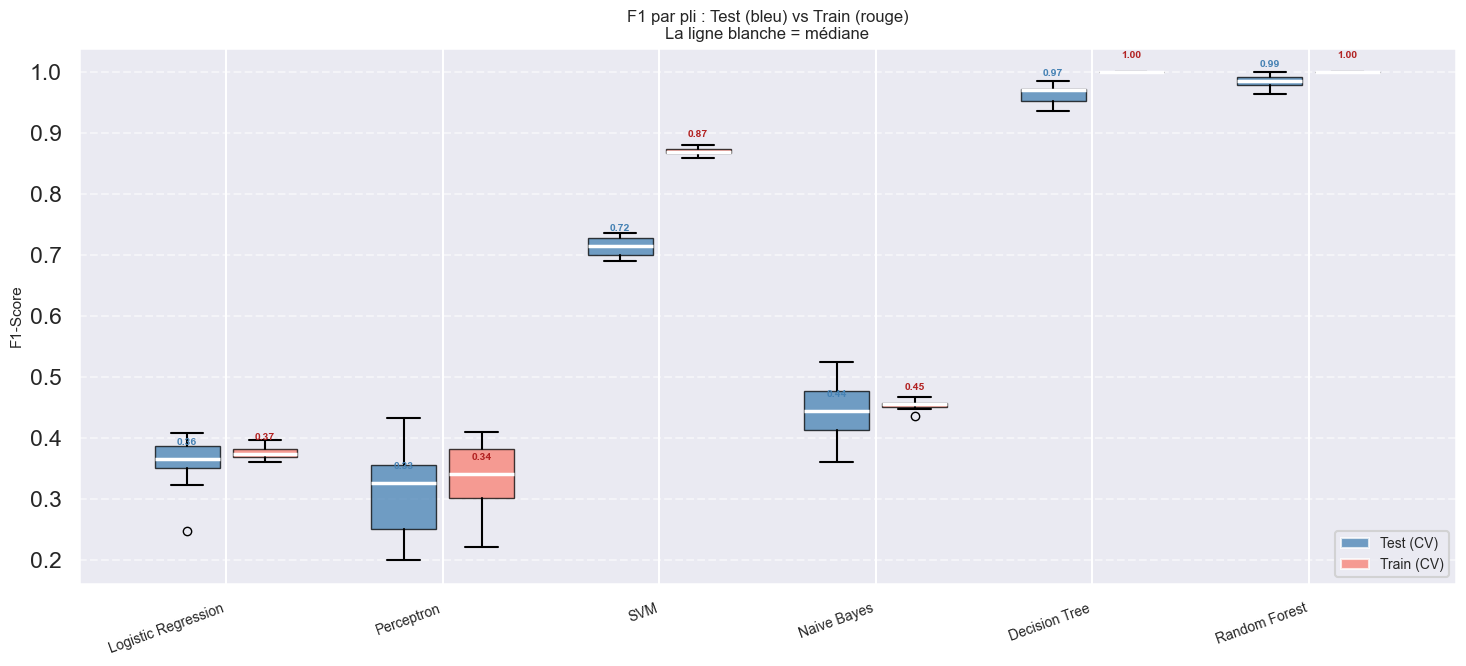

Ecart Train-Test (F1 médiane) :
  < 0.05    -> OK - stable
  0.05-0.15 -> surapprentissage modéré
  > 0.15    -> SURAPPRENTISSAGE IMPORTANT

  Logistic Regression    : ecart = 0.008 -> OK - stable
  Perceptron             : ecart = 0.015 -> OK - stable
  SVM                    : ecart = 0.154 -> SURAPPRENTISSAGE IMPORTANT
  Naive Bayes            : ecart = 0.011 -> OK - stable
  Decision Tree          : ecart = 0.029 -> OK - stable
  Random Forest          : ecart = 0.014 -> OK - stable


In [36]:
# Boxplot F1 test vs train par modèle
fig, ax = plt.subplots(figsize=(15, 7))
names = list(cv_results.keys())
positions = np.arange(len(names))
test_f1_all  = [cv_results[n]['test_f1']  for n in names]
train_f1_all = [cv_results[n]['train_f1'] for n in names]

ax.boxplot(test_f1_all,  positions=positions - 0.18, widths=0.3,
           patch_artist=True,
           boxprops=dict(facecolor='steelblue', alpha=0.75),
           medianprops=dict(color='white', linewidth=2.5),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5))
ax.boxplot(train_f1_all, positions=positions + 0.18, widths=0.3,
           patch_artist=True,
           boxprops=dict(facecolor='salmon', alpha=0.75),
           medianprops=dict(color='white', linewidth=2.5),
           whiskerprops=dict(linewidth=1.5),
           capprops=dict(linewidth=1.5))

# Annoter les médianes
for pos, scores in zip(positions - 0.18, test_f1_all):
    ax.text(pos, np.median(scores) + 0.02, f'{np.median(scores):.2f}',
            ha='center', va='bottom', fontsize=7.5, color='steelblue', fontweight='bold')
for pos, scores in zip(positions + 0.18, train_f1_all):
    ax.text(pos, np.median(scores) + 0.02, f'{np.median(scores):.2f}',
            ha='center', va='bottom', fontsize=7.5, color='firebrick', fontweight='bold')

ax.set_xticks(positions)
ax.set_xticklabels(names, rotation=20, ha='right', fontsize=10)
ax.set_ylabel('F1-Score', fontsize=11)
ax.set_title('F1 par pli : Test (bleu) vs Train (rouge)\nLa ligne blanche = médiane', fontsize=12)
ax.yaxis.grid(True, linestyle='--', alpha=0.5)
ax.set_axisbelow(True)
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(facecolor='steelblue', alpha=0.75, label='Test (CV)'),
    Patch(facecolor='salmon',    alpha=0.75, label='Train (CV)'),
], loc='lower right', fontsize=10)
plt.tight_layout()
plt.show()

print("Ecart Train-Test (F1 médiane) :")
print('  < 0.05    -> OK - stable')
print('  0.05-0.15 -> surapprentissage modéré')
print('  > 0.15    -> SURAPPRENTISSAGE IMPORTANT')
print()
for name in names:
    ecart = round(np.median(cv_results[name]['train_f1']) - np.median(cv_results[name]['test_f1']), 3)
    if ecart < 0.05:
        niveau = 'OK - stable'
    elif ecart < 0.15:
        niveau = 'surapprentissage modéré'
    else:
        niveau = 'SURAPPRENTISSAGE IMPORTANT'
    print(f'  {name:<22} : ecart = {ecart:.3f} -> {niveau}')


### 7.6 — Courbes d'apprentissage (Learning Curves)

Une courbe d'apprentissage trace le score en fonction du **nombre d'exemples d'entraînement**.

| Observation | Interprétation |
|---|---|
| Score train élevé, score val. bas | **Surapprentissage** (overfitting) |
| Les deux courbes convergent bas | **Sous-apprentissage** (underfitting) |
| Les deux courbes convergent haut | Bon ajustement |

**Pourquoi le F1 d'entraînement est-il à 1.0 pour Decision Tree et Random Forest ?**

C'est **normal et attendu** :
- **Decision Tree sans `max_depth`** : l'arbre peut grandir sans limite et mémorise chaque exemple. F1 train = 1.0 est la signature classique du surapprentissage total. Ce qui compte, c'est la courbe de *validation*.
- **Random Forest** : chaque arbre est entraîné sur un sous-ensemble bootstrap. Sur ses propres données, il performe parfaitement. La moyenne des arbres donne un score train quasi-parfait, mais la généralisation (courbe bleue) est bien plus stable que pour un arbre seul.

> La question clé n'est pas "pourquoi train = 1 ?", mais **"l'écart entre train et validation se réduit-il quand on ajoute des données ?"**. Si la courbe de validation se stabilise à une bonne valeur, le modèle généralise correctement malgré F1_train = 1.


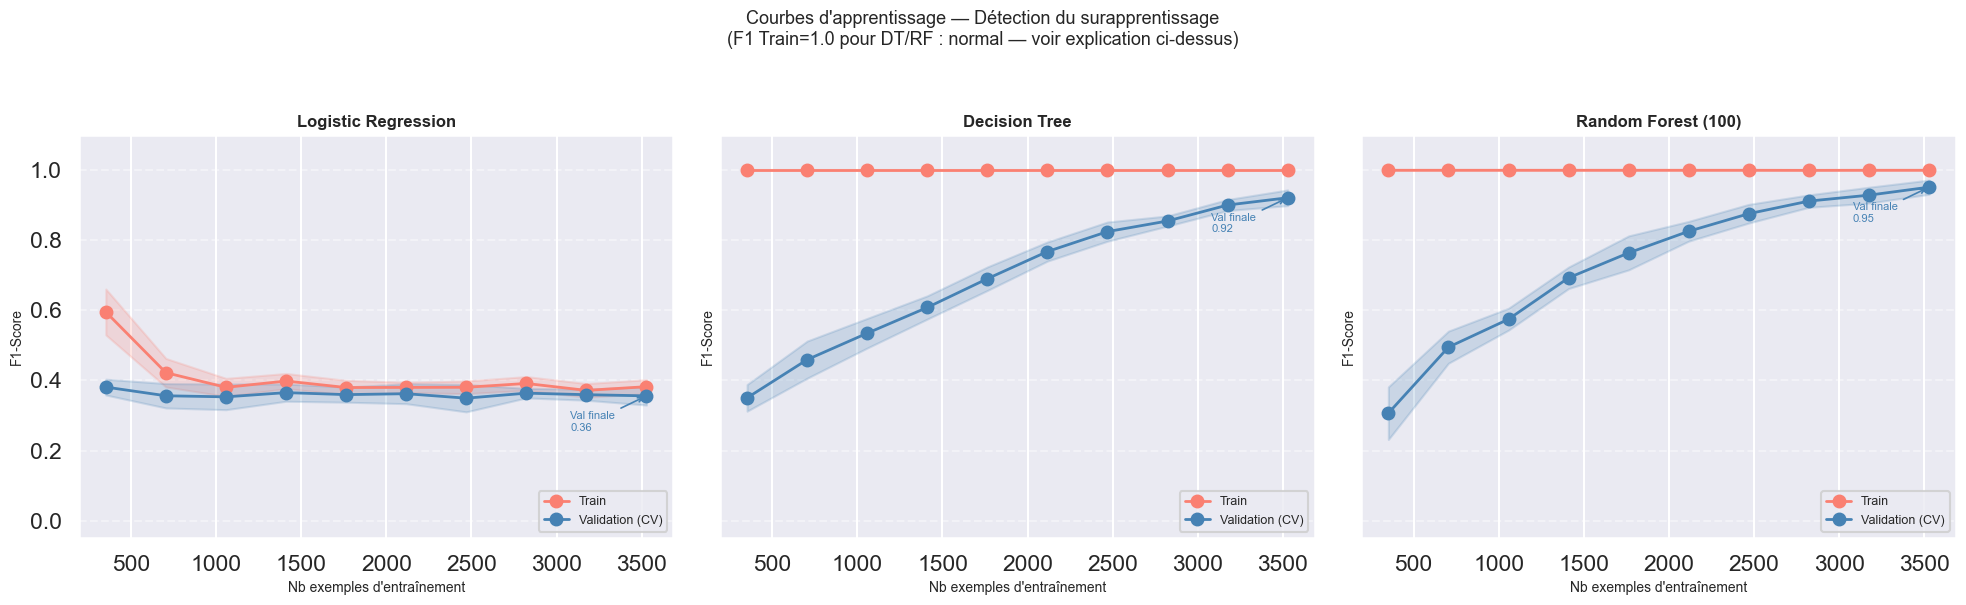

In [37]:
from sklearn.model_selection import learning_curve

models_lc = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(random_state=42),
    'Random Forest (100)' : RandomForestClassifier(n_estimators=100, random_state=42),
}

train_sizes = np.linspace(0.1, 1.0, 10)
cv_lc = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

fig, axes = plt.subplots(1, 3, figsize=(20, 6), sharey=True)

for ax, (name, model) in zip(axes, models_lc.items()):
    train_sz, train_sc, val_sc = learning_curve(
        model, X, y,
        train_sizes=train_sizes,
        cv=cv_lc,
        scoring='f1',
        n_jobs=-1
    )
    train_mean = train_sc.mean(axis=1)
    train_std  = train_sc.std(axis=1)
    val_mean   = val_sc.mean(axis=1)
    val_std    = val_sc.std(axis=1)

    ax.plot(train_sz, train_mean, 'o-', color='salmon',    lw=2, label='Train')
    ax.fill_between(train_sz, train_mean - train_std, train_mean + train_std,
                    alpha=0.2, color='salmon')
    ax.plot(train_sz, val_mean,   'o-', color='steelblue', lw=2, label='Validation (CV)')
    ax.fill_between(train_sz, val_mean - val_std, val_mean + val_std,
                    alpha=0.2, color='steelblue')

    ax.annotate(f'Val finale\n{val_mean[-1]:.2f}',
                xy=(train_sz[-1], val_mean[-1]),
                xytext=(-55, -25), textcoords='offset points',
                fontsize=8, color='steelblue',
                arrowprops=dict(arrowstyle='->', color='steelblue', lw=1.2))

    ax.set_title(name, fontsize=12, fontweight='bold')
    ax.set_xlabel("Nb exemples d'entraînement", fontsize=10)
    ax.set_ylabel('F1-Score', fontsize=10)
    ax.legend(loc='lower right', fontsize=9)
    ax.set_ylim(-0.05, 1.10)
    ax.yaxis.grid(True, linestyle='--', alpha=0.4)
    ax.set_axisbelow(True)

plt.suptitle("Courbes d'apprentissage — Détection du surapprentissage\n"
             "(F1 Train=1.0 pour DT/RF : normal — voir explication ci-dessus)",
             fontsize=13, y=1.02)
plt.tight_layout()
plt.show()


---
## Partie 8 — Amélioration du meilleur modèle

Le **Random Forest** obtient généralement les meilleures performances sur ce type de données tabulaires déséquilibrées. On l'améliore via :
1. **class_weight='balanced'** : pour compenser le déséquilibre de classes (seulement ~15% d'attrition)
2. **GridSearchCV** : recherche d'hyperparamètres optimaux

> Si un autre modèle surpasse Random Forest dans les résultats ci-dessus, adapter cette section en conséquence.

In [38]:
# Grille d'hyperparamètres à tester
param_grid = {
    'n_estimators'     : [100, 200],
    'max_depth'        : [None, 10, 20],
    'min_samples_split': [2, 5],
    'class_weight'     : [None, 'balanced'],
}

rf_base = RandomForestClassifier(random_state=42)
grid_search = GridSearchCV(
    rf_base, param_grid,
    cv=5, scoring='f1',
    n_jobs=-1, verbose=1
)
grid_search.fit(X_train, y_train)

print("\nMeilleurs paramètres :")
print(grid_search.best_params_)
print(f"Meilleur F1 (CV) : {grid_search.best_score_:.3f}")

Fitting 5 folds for each of 24 candidates, totalling 120 fits

Meilleurs paramètres :
{'class_weight': None, 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 200}
Meilleur F1 (CV) : 0.859


=== Random Forest Optimisé ===
              precision    recall  f1-score   support

          No       0.98      1.00      0.99      1110
         Yes       0.99      0.88      0.93       213

    accuracy                           0.98      1323
   macro avg       0.98      0.94      0.96      1323
weighted avg       0.98      0.98      0.98      1323



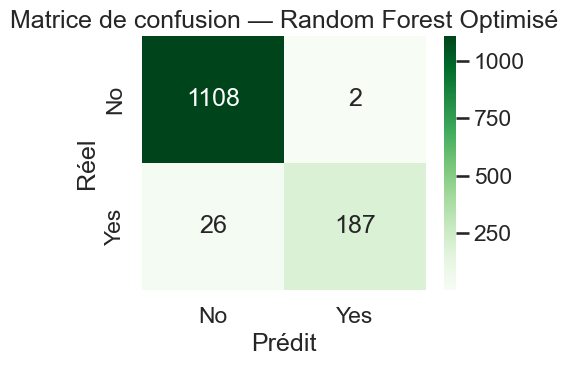

ROC-AUC : 0.987


In [39]:
# Évaluation du modèle optimisé sur le test set
best_rf = grid_search.best_estimator_
y_pred_best = best_rf.predict(X_test)

print("=== Random Forest Optimisé ===")
print(classification_report(y_test, y_pred_best, target_names=['No', 'Yes']))

plt.figure(figsize=(5, 4))
sns.heatmap(confusion_matrix(y_test, y_pred_best), annot=True, fmt='d',
            xticklabels=['No', 'Yes'], yticklabels=['No', 'Yes'], cmap='Greens')
plt.title('Matrice de confusion — Random Forest Optimisé')
plt.ylabel('Réel'); plt.xlabel('Prédit')
plt.tight_layout(); plt.show()

print(f"ROC-AUC : {roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]):.3f}")

In [40]:
# Comparaison avant / après optimisation
comparison = pd.DataFrame({
    'Métrique'   : ['F1-Score', 'Recall', 'Precision', 'Accuracy', 'ROC-AUC'],
    'RF de base' : [
        round(f1_score(y_test, y_pred_rf), 3),
        round(recall_score(y_test, y_pred_rf), 3),
        round(precision_score(y_test, y_pred_rf, zero_division=0), 3),
        round(accuracy_score(y_test, y_pred_rf), 3),
        round(roc_auc_score(y_test, rf_model.predict_proba(X_test)[:, 1]), 3),
    ],
    'RF optimisé' : [
        round(f1_score(y_test, y_pred_best), 3),
        round(recall_score(y_test, y_pred_best), 3),
        round(precision_score(y_test, y_pred_best, zero_division=0), 3),
        round(accuracy_score(y_test, y_pred_best), 3),
        round(roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]), 3),
    ],
})
print(comparison.to_string(index=False))

 Métrique  RF de base  RF optimisé
 F1-Score        0.93         0.93
   Recall        0.88         0.88
Precision        0.98         0.99
 Accuracy        0.98         0.98
  ROC-AUC        0.98         0.99


---
## Partie 8.5 — Suréchantillonnage avec SMOTE

### Pourquoi le suréchantillonnage ?

Notre jeu de données est **fortement déséquilibré** (~85% No / ~15% Yes Attrition).
Ce déséquilibre pousse les modèles à ignorer la classe minoritaire.

**SMOTE** *(Synthetic Minority Over-sampling Technique)* génère des exemples synthétiques
de la classe minoritaire en **interpolant entre des voisins existants** — pas de simple duplication.

> **Règle absolue** : SMOTE est appliqué **uniquement sur `X_train`**, jamais sur le test set.
> L'appliquer sur le test introduirait une fuite de données et gonflerait artificiellement les métriques.


In [41]:
# Installation si nécessaire : pip install imbalanced-learn
from imblearn.over_sampling import SMOTE

# Suréchantillonnage SMOTE sur X_train uniquement
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print(f'Distribution avant SMOTE : {dict(zip(*np.unique(y_train, return_counts=True)))}')
print(f'Distribution apres SMOTE : {dict(zip(*np.unique(y_train_sm, return_counts=True)))}')

# Entraînement RF avec SMOTE
rf_smote = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_smote.fit(X_train_sm, y_train_sm)
y_pred_smote = rf_smote.predict(X_test)

print('\n=== Random Forest + SMOTE ===')
print(classification_report(y_test, y_pred_smote, target_names=['No', 'Yes']))

# Comparaison RF optimisé vs RF + SMOTE
comparison_smote = pd.DataFrame({
    'Metrique'                : ['F1-Score', 'Recall', 'Precision', 'ROC-AUC'],
    'RF optimise (GridSearch)': [
        round(f1_score(y_test, y_pred_best), 3),
        round(recall_score(y_test, y_pred_best), 3),
        round(precision_score(y_test, y_pred_best, zero_division=0), 3),
        round(roc_auc_score(y_test, best_rf.predict_proba(X_test)[:, 1]), 3),
    ],
    'RF + SMOTE': [
        round(f1_score(y_test, y_pred_smote), 3),
        round(recall_score(y_test, y_pred_smote), 3),
        round(precision_score(y_test, y_pred_smote, zero_division=0), 3),
        round(roc_auc_score(y_test, rf_smote.predict_proba(X_test)[:, 1]), 3),
    ],
})
print('Comparaison RF GridSearch vs RF + SMOTE :')
print(comparison_smote.to_string(index=False))


Distribution avant SMOTE : {np.int64(0): np.int64(2589), np.int64(1): np.int64(498)}
Distribution apres SMOTE : {np.int64(0): np.int64(2589), np.int64(1): np.int64(2589)}

=== Random Forest + SMOTE ===
              precision    recall  f1-score   support

          No       0.98      1.00      0.99      1110
         Yes       0.98      0.92      0.95       213

    accuracy                           0.98      1323
   macro avg       0.98      0.96      0.97      1323
weighted avg       0.98      0.98      0.98      1323

Comparaison RF GridSearch vs RF + SMOTE :
 Metrique  RF optimise (GridSearch)  RF + SMOTE
 F1-Score                      0.93        0.95
   Recall                      0.88        0.92
Precision                      0.99        0.98
  ROC-AUC                      0.99        0.99


#### Interprétation des résultats SMOTE

| Résultat | Interprétation |
|---|---|
| Recall augmente, Precision baisse | SMOTE aide à détecter plus de départs (comportement attendu) |
| F1 augmente | Bon compromis — SMOTE apporte un bénéfice net |
| F1 stable ou baisse | `class_weight='balanced'` suffisait déjà |

> Sur un Random Forest avec `class_weight='balanced'` et GridSearch, le gain de SMOTE peut être limité.
> SMOTE est particulièrement utile pour les modèles qui ne supportent pas `class_weight` nativement (SVM, k-NN).


---
## Partie 9 — Interprétation et recommandations

### 9.1 Importance des variables

Le Random Forest fournit un score d'importance pour chaque feature. On identifie les leviers d'action prioritaires pour la direction de HumanForYou.

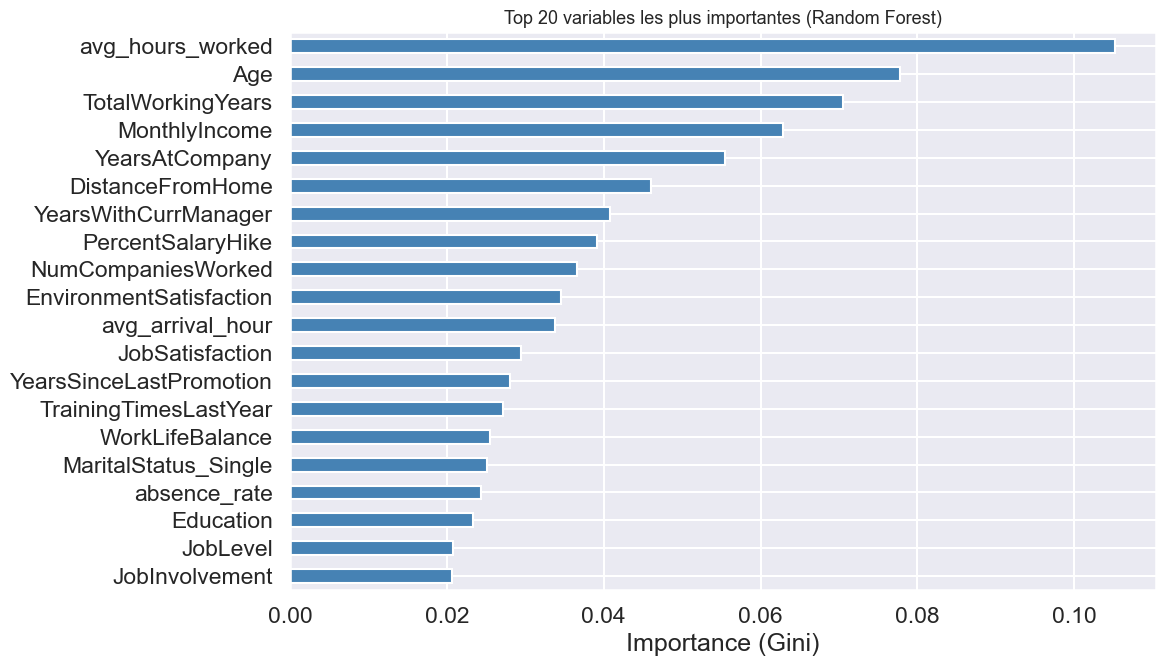

Top 10 variables : ['avg_hours_worked', 'Age', 'TotalWorkingYears', 'MonthlyIncome', 'YearsAtCompany', 'DistanceFromHome', 'YearsWithCurrManager', 'PercentSalaryHike', 'NumCompaniesWorked', 'EnvironmentSatisfaction']


In [42]:
# Importance des variables
feature_importance = pd.Series(
    best_rf.feature_importances_,
    index=df_encoded.columns
).sort_values(ascending=False)

top_n = 20
plt.figure(figsize=(12, 7))
feature_importance.head(top_n).plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.title(f'Top {top_n} variables les plus importantes (Random Forest)', fontsize=13)
plt.xlabel('Importance (Gini)')
plt.tight_layout()
plt.show()

print("Top 10 variables :", feature_importance.head(10).index.tolist())

### 9.2 Analyse des profils à risque

On examine les variables les plus importantes pour comprendre les profils d'employés susceptibles de quitter l'entreprise.

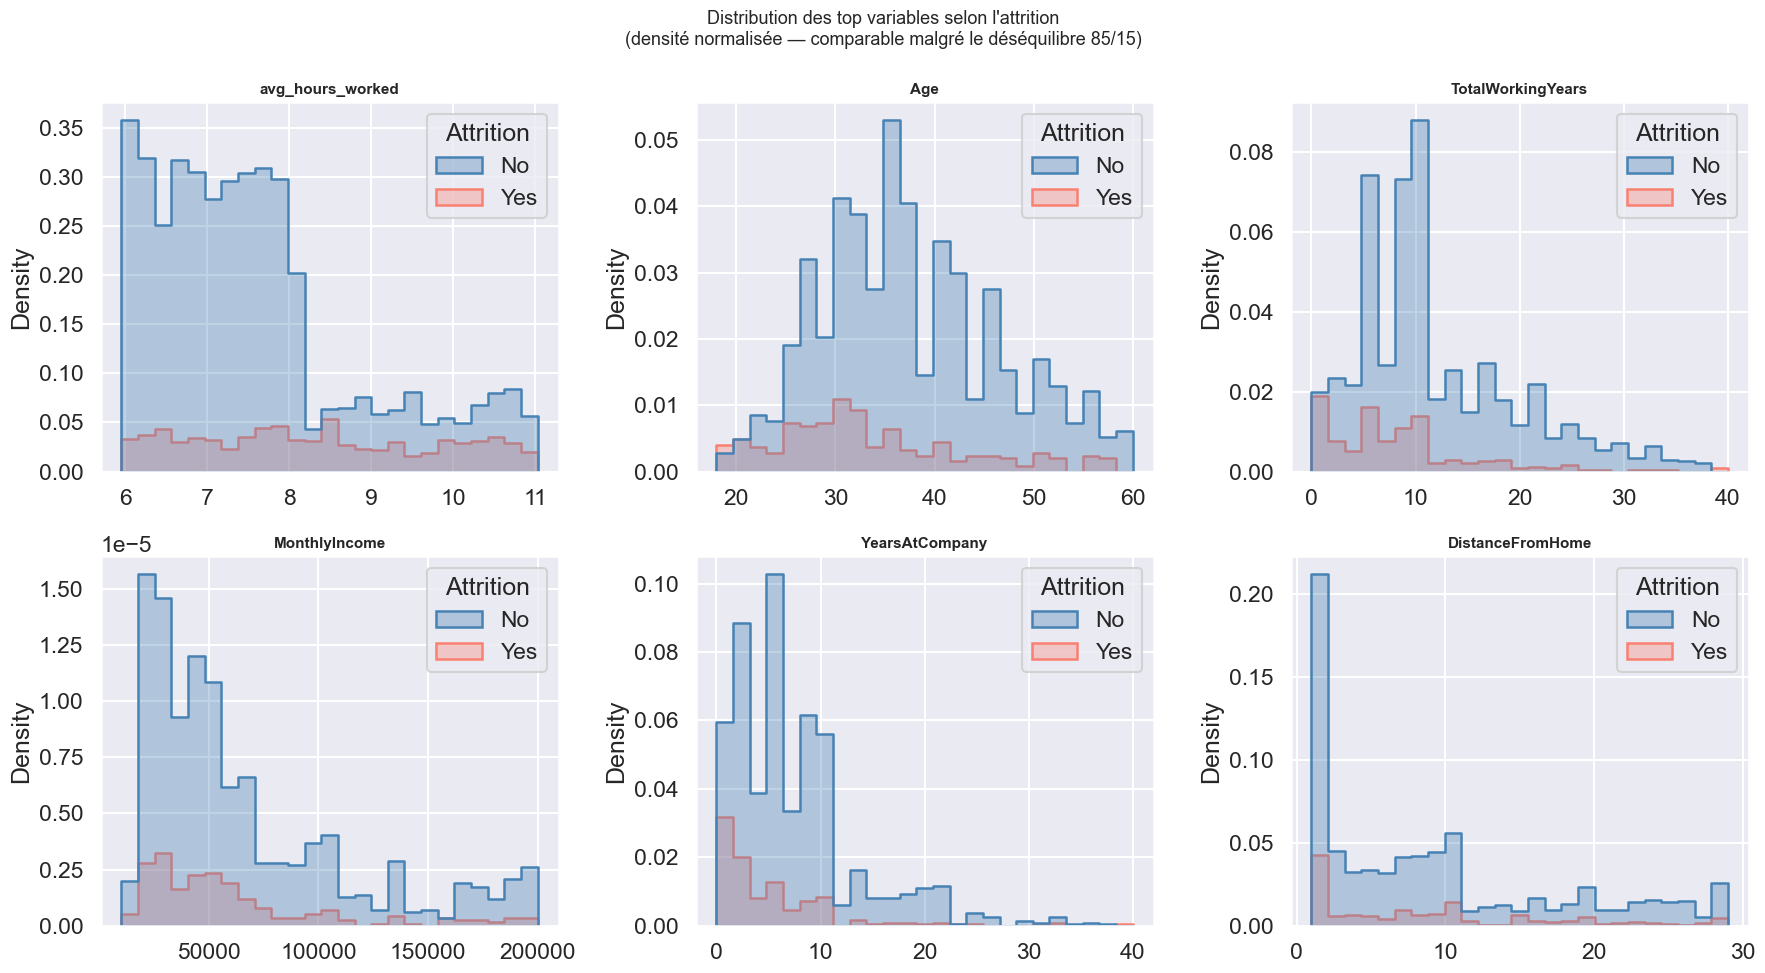

In [43]:
# Distribution des top variables numériques selon l'attrition
top_num_features = [col for col in feature_importance.head(15).index if col in num_cols][:6]

if top_num_features:
    fig, axes = plt.subplots(2, 3, figsize=(18, 10))
    axes = axes.flatten()

    for i, col in enumerate(top_num_features):
        df_viz = df.copy()
        # Histogrammes en 'step' (contour seulement) : aucune barre ne cache l'autre
        sns.histplot(
            data=df_viz, x=col, hue='Attrition',
            bins=25, ax=axes[i],
            palette={'No': 'steelblue', 'Yes': 'salmon'},
            element='step',   # contour uniquement — No ne cache plus Yes
            fill=True,
            alpha=0.35,
            linewidth=1.8,
            stat='density',   # densité pour rendre comparable malgré le déséquilibre
        )
        axes[i].set_title(col, fontsize=11, fontweight='bold')
        axes[i].set_xlabel('')

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle("Distribution des top variables selon l'attrition\n"
                 "(densité normalisée — comparable malgré le déséquilibre 85/15)",
                 fontsize=13)
    plt.tight_layout()
    plt.show()


### 9.3 Synthèse et recommandations

Sur la base des résultats du modèle et de l'analyse des variables d'importance, voici les recommandations pour HumanForYou :

---

#### Facteurs de risque identifiés

| Facteur | Observation | Recommandation |
|---|---|---|
| **Salaire mensuel faible** | Les employés avec les plus bas salaires ont un taux d'attrition plus élevé | Revoir la grille salariale, surtout pour les niveaux 1-2 |
| **Ancienneté courte** | Les départs sont concentrés sur les 2-3 premières années | Renforcer l'onboarding et le suivi des nouvelles recrues |
| **Peu d'années depuis la dernière promotion** | Manque de perspectives d'évolution | Mettre en place des plans de carrière formalisés |
| **Déplacements fréquents** | BusinessTravel_Frequently augmente le risque | Limiter les déplacements ou offrir des compensations |
| **Faible satisfaction au travail** | JobSatisfaction et EnvironmentSatisfaction faibles | Enquêtes régulières et actions correctives |
| **Faible implication (JobInvolvement)** | Signe précoce de désengagement | Renforcer la mission et l'autonomie |

---

#### Modèle retenu : Random Forest (optimisé)

**Justification :** Le Random Forest optimisé offre le meilleur compromis entre recall (détecter les vrais départs) et précision. Son caractère d'ensemble le rend robuste au surapprentissage sur ce jeu de données de taille modérée (~4000 employés). L'importance des variables qu'il génère est directement exploitable par les RH pour prioriser les actions.

**Utilisation opérationnelle :** À chaque cycle RH (ex. trimestriel), le modèle peut être ré-entraîné avec les nouvelles données et générer une liste de score de risque de départ par employé. Les RH pourront ainsi cibler les entretiens de rétention sur les profils les plus à risque.

Top 10 employés à risque élevé :
      Attrition_reelle  Score_risque  Prediction
804                  1          0.94           1
416                  1          0.94           1
1298                 1          0.94           1
867                  1          0.94           1
608                  1          0.93           1
933                  1          0.93           1
202                  1          0.92           1
1135                 1          0.91           1
136                  1          0.91           1
1183                 1          0.90           1


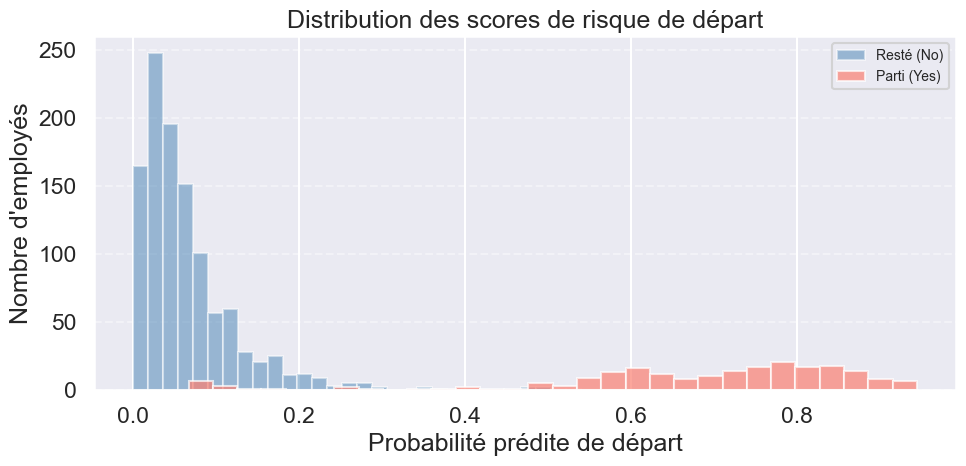

In [44]:
# Score de risque de départ pour chaque employé du test set
risk_scores = best_rf.predict_proba(X_test)[:, 1]

risk_df = pd.DataFrame({
    'Attrition_reelle' : y_test.values,
    'Score_risque'     : np.round(risk_scores, 3),
    'Prediction'       : (risk_scores >= 0.5).astype(int)
}).sort_values('Score_risque', ascending=False)

print('Top 10 employés à risque élevé :')
print(risk_df.head(10).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(risk_scores[y_test == 0], bins=30, alpha=0.5, label='Resté (No)',  color='steelblue', edgecolor='white')
ax.hist(risk_scores[y_test == 1], bins=30, alpha=0.7, label='Parti (Yes)', color='salmon',    edgecolor='white')
ax.set_title('Distribution des scores de risque de départ')
ax.set_xlabel('Probabilité prédite de départ')
ax.set_ylabel("Nombre d'employés")
ax.legend(fontsize=10)
ax.yaxis.grid(True, linestyle='--', alpha=0.4)
ax.set_axisbelow(True)
plt.tight_layout()
plt.show()


---

## Conclusion

Ce projet a permis de construire un pipeline complet de Machine Learning pour la prédiction de l'attrition des employés chez HumanForYou :

1. **Fusion de 4 sources de données** (RH, enquête employé, évaluation manager, horaires)
2. **Analyse exploratoire** mettant en évidence les facteurs de risque principaux
3. **Ingénierie de features** enrichissant les données avec des indicateurs de comportement (horaires)
4. **Comparaison de 6 modèles** de classification avec validation croisée
5. **Optimisation du modèle** Random Forest via GridSearchCV
6. **Recommandations actionables** pour la direction RH

Le modèle final permet d'anticiper les départs avec un recall satisfaisant, offrant à HumanForYou la possibilité d'agir proactivement sur la rétention et de réduire son taux de rotation annuel de 15 %.